# Tanzania Tourism Expenditure Prediction
### Full Pipeline: Ridge · Random Forest · XGBoost · Error Analysis · SHAP

**Primary KPIs:** Mean Absolute Error (MAE) · R² Score

> **Currency note:** All spend values are in Tanzanian Shillings (TZS).
> 1,000,000 TZS ≈ 340–350 EUR at current rates.

### Environment setup
```
pip install -r requirements.txt
```
Required: `numpy==2.4.2` · `pandas==3.0.1` · `scikit-learn==1.8.0`
· `xgboost==3.2.0` · `shap==0.51.0` · `matplotlib==3.10.8` · `seaborn==0.13.2`


---
## 1. Imports

In [5]:
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 50

print("All imports OK")
print(f"  numpy       {np.__version__}")
print(f"  pandas      {pd.__version__}")
print(f"  shap        {shap.__version__}")

All imports OK
  numpy       2.4.2
  pandas      3.0.1
  shap        0.51.0


### Helper: metric summary function

In [6]:
def eval_metrics(y_true, y_pred, label=""):
    """Return MAE, R²(TZS), R²(log) and optionally print them."""
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    r2_log = r2_score(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None)))
    if label:
        print(f"{label:35s}  MAE={mae:>11,.0f} TZS  R²={r2:>6.3f}  R²(log)={r2_log:>6.3f}")
    return mae, r2, r2_log

---
## 2. Load Data

In [7]:
train = pd.read_csv("../data/Train.csv")
print(f"Shape: {train.shape}")
train.head(10)

Shape: (4809, 23)


,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,No,No,No,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,No,Yes,Yes,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0
5,tour_1005,UNITED KINGDOM,25-44,NaN,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,No,No,No,No,Yes,Yes,No,9.0,3.0,Cash,Yes,Wildlife,120950.0
6,tour_1007,SOUTH AFRICA,45-64,Alone,0.0,1.0,Business,Mountain climbing,"Friends, relatives",Independent,No,No,No,No,No,No,No,9.0,0.0,Cash,Yes,Friendly People,466140.0
7,tour_1008,UNITED STATES OF AMERICA,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10.0,3.0,Cash,Yes,Friendly People,3480750.0
8,tour_101,NIGERIA,25-44,Alone,0.0,1.0,Leisure and Holidays,Cultural tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,4.0,0.0,Cash,Yes,NaN,994500.0
9,tour_1011,INDIA,25-44,Alone,1.0,0.0,Business,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,5.0,0.0,Credit Card,Yes,Friendly People,2486250.0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   str    
 1   country                4809 non-null   str    
 2   age_group              4809 non-null   str    
 3   travel_with            3695 non-null   str    
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   str    
 7   main_activity          4809 non-null   str    
 8   info_source            4809 non-null   str    
 9   tour_arrangement       4809 non-null   str    
 10  package_transport_int  4809 non-null   str    
 11  package_accomodation   4809 non-null   str    
 12  package_food           4809 non-null   str    
 13  package_transport_tz   4809 non-null   str    
 14  package_sightseeing    4809 non-null   str    
 15  package_guided_

In [9]:
train.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


---
## 3. EDA

### 3.1 Target Distribution

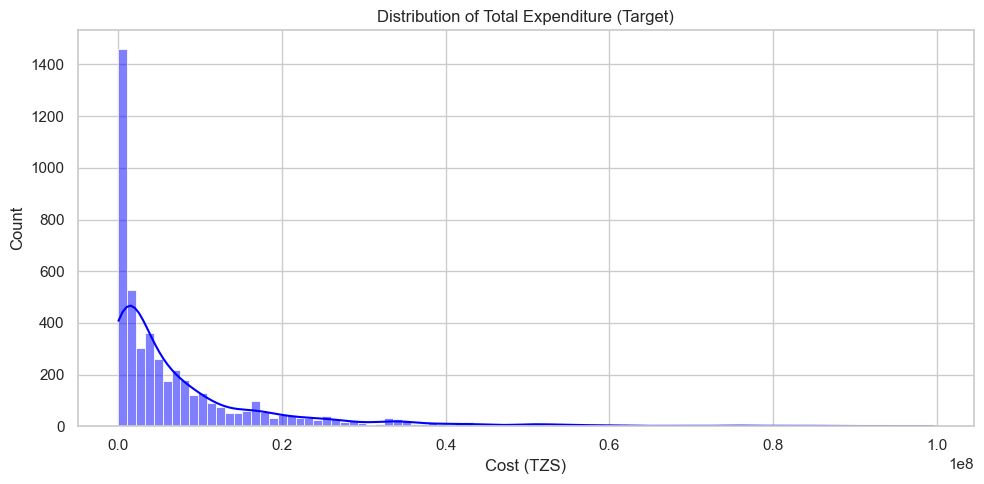

count    4.809000e+03
mean     8.114389e+06
std      1.222490e+07
min      4.900000e+04
25%      8.121750e+05
50%      3.397875e+06
75%      9.945000e+06
max      9.953288e+07
Name: total_cost, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(train['total_cost'], kde=True, color='blue')
plt.title('Distribution of Total Expenditure (Target)')
plt.xlabel('Cost (TZS)')
plt.tight_layout()
plt.show()
print(train['total_cost'].describe())

**Observation:** Spending is heavily right-skewed.
Median ≈ 3.4M TZS (~1,150 EUR); Max ≈ 99M TZS (~34,000 EUR).
A log-transformation of the target is applied before training.

### 3.2 Missing Values

Columns with missing values:
travel_with        1114
most_impressing     313
total_male            5
total_female          3
dtype: int64


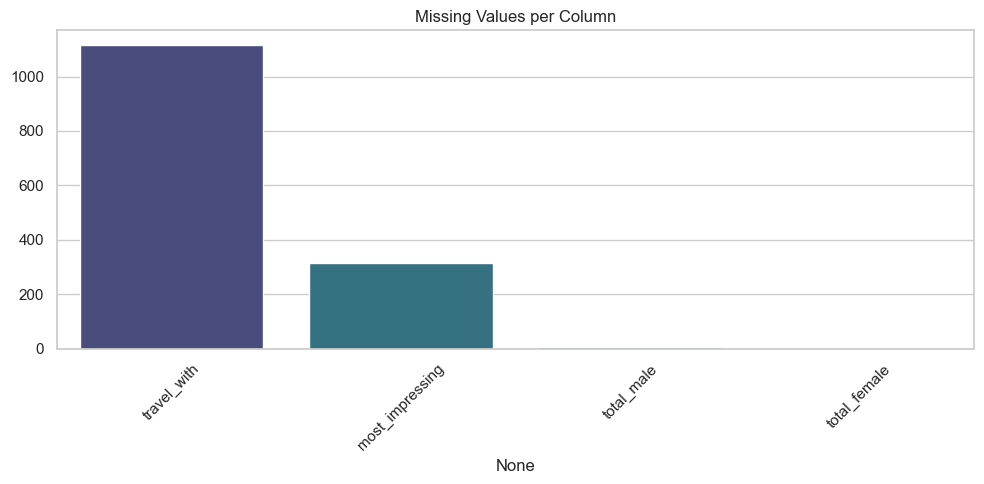

In [11]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y=missing.values, palette="viridis")
plt.title("Missing Values per Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Outlier Detection

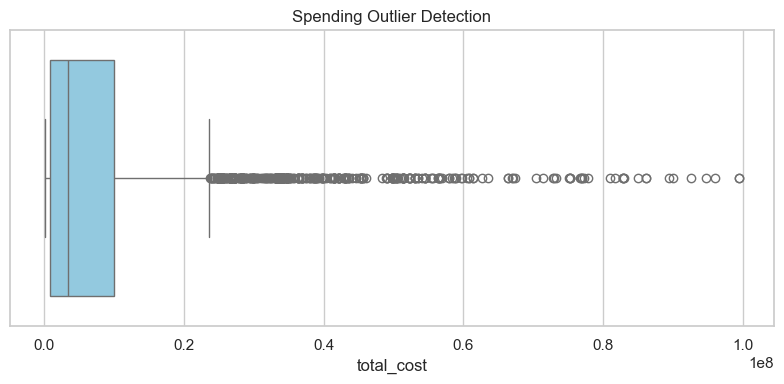

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=train['total_cost'], color='skyblue')
plt.title("Spending Outlier Detection")
plt.tight_layout()
plt.show()

### 3.4 Top Tourist Countries

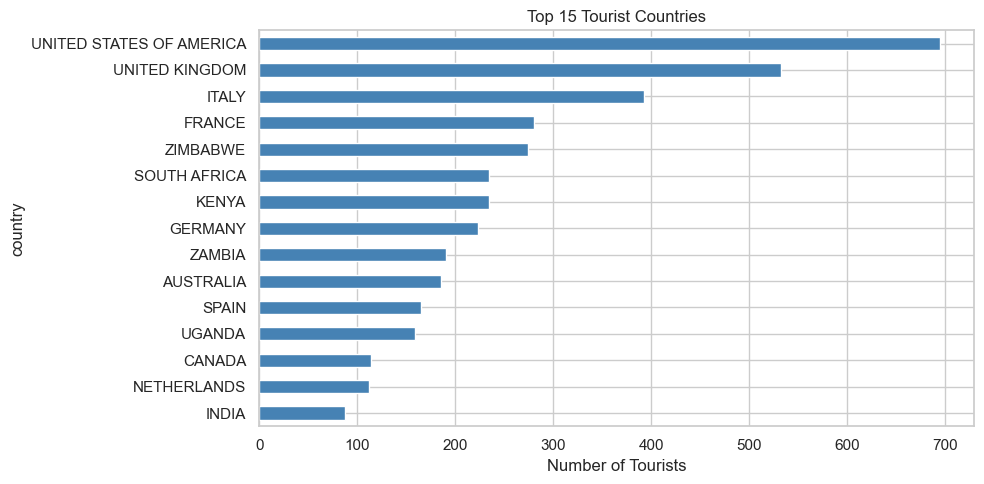

In [13]:
top_countries = train['country'].value_counts().head(15)
plt.figure(figsize=(10, 5))
top_countries.plot(kind='barh', color='steelblue')
plt.title('Top 15 Tourist Countries')
plt.xlabel('Number of Tourists')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.5 Categorical Features vs. Cost

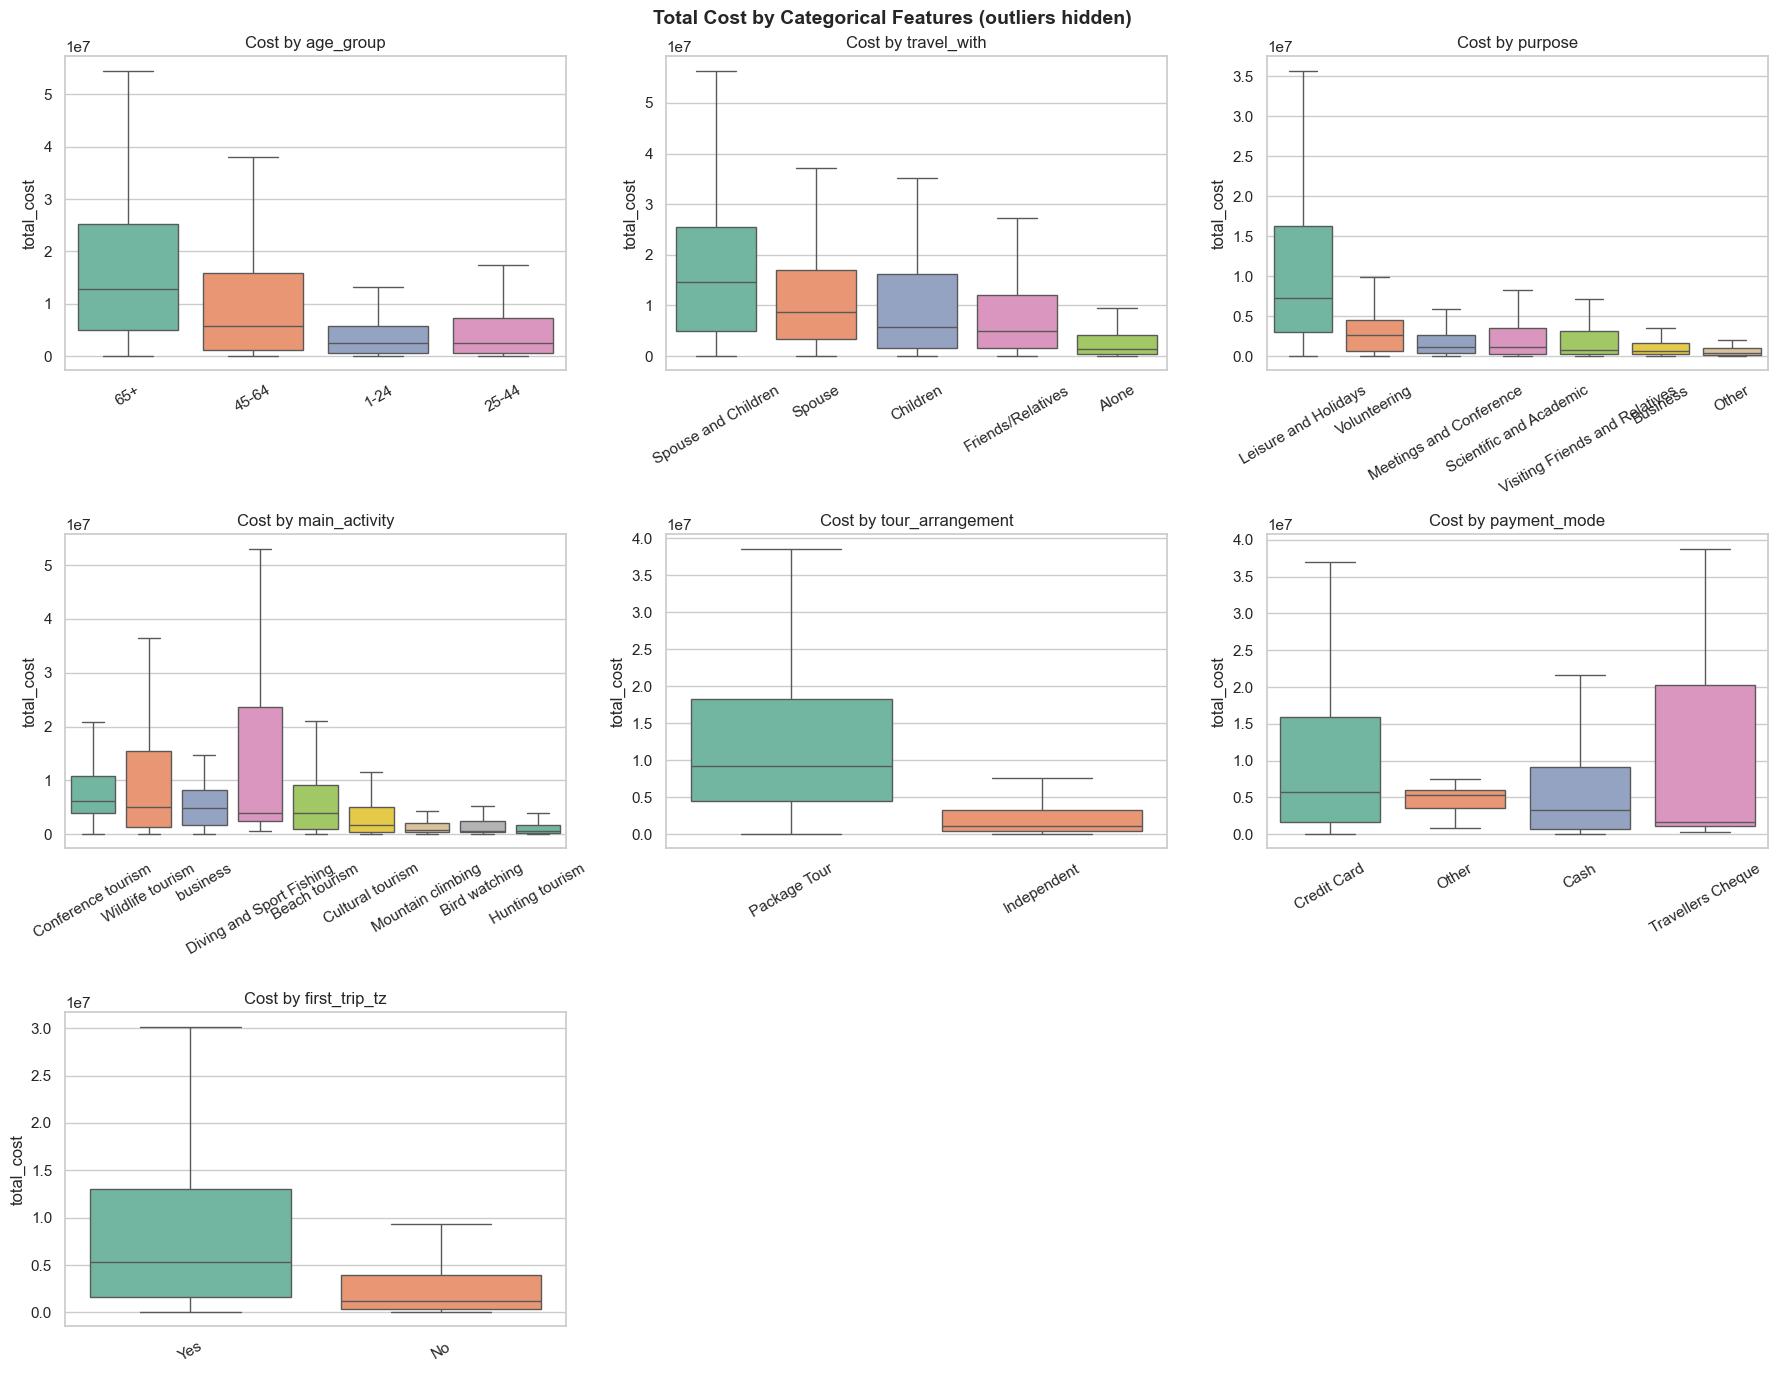

In [14]:
cat_cols = ['age_group', 'travel_with', 'purpose', 'main_activity',
            'tour_arrangement', 'payment_mode', 'first_trip_tz']
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = train.groupby(col)['total_cost'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='total_cost', order=order, ax=axes[i],
                palette='Set2', showfliers=False)
    axes[i].set_title(f'Cost by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Total Cost by Categorical Features (outliers hidden)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Package Inclusions

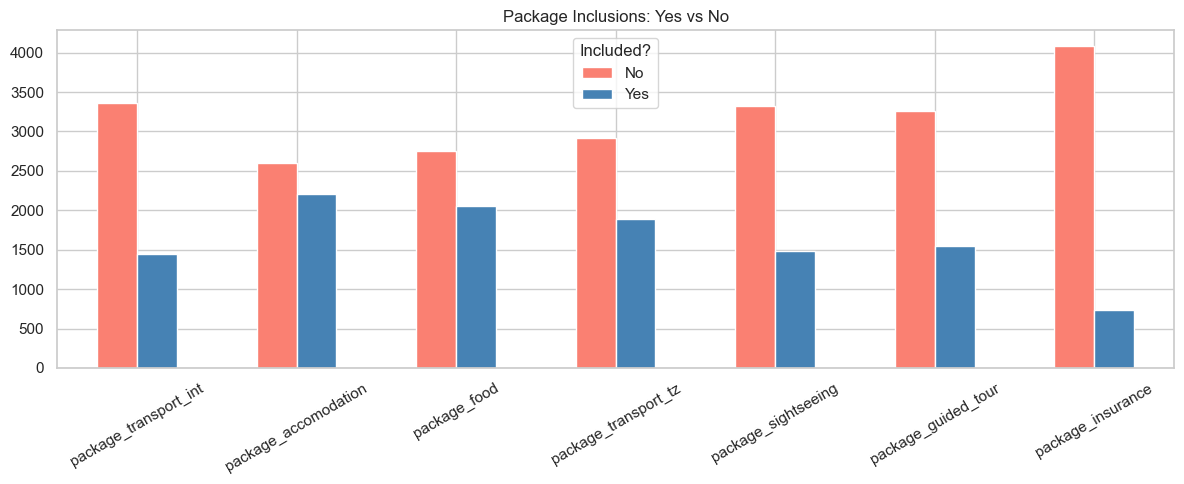

In [15]:
package_cols = ['package_transport_int', 'package_accomodation', 'package_food',
                'package_transport_tz', 'package_sightseeing',
                'package_guided_tour', 'package_insurance']
package_counts = train[package_cols].apply(lambda x: x.value_counts()).T.fillna(0)
package_counts.plot(kind='bar', figsize=(12, 5), color=['salmon', 'steelblue'])
plt.title('Package Inclusions: Yes vs No')
plt.xticks(rotation=30)
plt.legend(title='Included?')
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning

**Rule:** Only stateless/deterministic operations here.
Statistics-derived transforms (country grouping, night capping) are
deferred until *after* the split to prevent data leakage.

### 4.1 Stateless Imputation

In [16]:
train['travel_with']     = train['travel_with'].fillna('Alone')
train['total_female']    = train['total_female'].fillna(0)
train['total_male']      = train['total_male'].fillna(0)
train['most_impressing'] = train['most_impressing'].fillna('No Comment')
print("Missing after imputation:")
print(train.isnull().sum()[train.isnull().sum() > 0])

Missing after imputation:
Series([], dtype: int64)


### 4.2 Type Conversions

In [17]:
train['total_female'] = train['total_female'].astype(int)
train['total_male']   = train['total_male'].astype(int)
print("Types converted.")

Types converted.


### 4.3 Fix Typos

In [18]:
train['country']   = train['country'].replace('SWIZERLAND', 'SWITZERLAND')
train['age_group'] = train['age_group'].replace('24-Jan', '1-24')
print("Unique age groups:", train['age_group'].unique())

Unique age groups: <StringArray>
['45-64', '25-44', '1-24', '65+']
Length: 4, dtype: str


### 4.4 Binary Encoding Yes/No → 1/0

In [19]:
binary_cols = [c for c in train.columns if c.startswith('package_')] + ['first_trip_tz']
for col in binary_cols:
    train[col] = train[col].map({'Yes': 1, 'No': 0})
print(f"Mapped {len(binary_cols)} columns to binary.")

Mapped 8 columns to binary.


### 4.5 Ensure At Least 1 Person per Trip

In [20]:
train['total_people'] = train['total_female'] + train['total_male']
zero_mask = train['total_people'] == 0
if zero_mask.any():
    print(f"Fixing {zero_mask.sum()} records with 0 travelers.")
    train.loc[zero_mask, 'total_male'] = 1
    train['total_people'] = train['total_female'] + train['total_male']
print(f"total_people >= 1: {(train['total_people'] >= 1).all()}")

Fixing 17 records with 0 travelers.
total_people >= 1: True


### 4.6 Drop Non-Predictive Columns & Zero-Cost Records

In [21]:
train = train.drop(columns=['ID', 'most_impressing'])
train = train[train['total_cost'] > 0]
print(f"Final shape: {train.shape}")

Final shape: (4809, 22)


---
## 5. Train / Validation / Test Split

> ⚠️ Split happens **before** any statistics-derived transforms.

In [22]:
X = train.drop(columns=['total_cost'])
y = train['total_cost']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test,  y_val,  y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (15%)")
print(f"Test Set:       {X_test.shape[0]} rows (15%)")

Training Set:   3366 rows (70%)
Validation Set: 721 rows (15%)
Test Set:       722 rows (15%)


---
## 6. Statistics-Derived Transforms (Post-Split, X_train only)

### 6.1 Country Grouping

In [23]:
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

threshold = 10
country_counts_train = X_train['country'].value_counts()
rare_countries = country_counts_train[country_counts_train < threshold].index

n_before = X_train['country'].nunique()
for df in [X_train, X_val, X_test]:
    df['country'] = df['country'].apply(lambda x: 'Other' if x in rare_countries else x)
print(f"Country vocab: {n_before} → {X_train['country'].nunique()} unique (train).")

Country vocab: 101 → 36 unique (train).


### 6.2 Night Duration Capping

In [24]:
max_nights = int(np.percentile(
    pd.concat([X_train['night_mainland'], X_train['night_zanzibar']]).dropna(), 95))
max_nights = max(max_nights, 45)
for df in [X_train, X_val, X_test]:
    df['night_mainland'] = df['night_mainland'].clip(upper=max_nights)
    df['night_zanzibar'] = df['night_zanzibar'].clip(upper=max_nights)
print(f"Night cap: {max_nights} nights (95th pct of X_train).")

Night cap: 45 nights (95th pct of X_train).


---
## 7. Log-Transform Target & Baseline

In [25]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

baseline_pred_val  = [y_train.mean()] * len(y_val)
baseline_pred_test = [y_train.mean()] * len(y_test)

baseline_val_mae,  baseline_val_r2,  _ = eval_metrics(y_val,  baseline_pred_val,  "Baseline val")
baseline_test_mae, baseline_test_r2, _ = eval_metrics(y_test, baseline_pred_test, "Baseline test")

Baseline val                         MAE=  8,107,515 TZS  R²=-0.001  R²(log)=-0.482
Baseline test                        MAE=  7,642,071 TZS  R²=-0.001  R²(log)=-0.430


---
## 8. Preprocessing Pipeline

In [26]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
num_features = X_train.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical ({len(cat_features)}): {cat_features}")
print(f"Numerical   ({len(num_features)}): {num_features}")

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

X_train_pre = preprocessor.fit_transform(X_train)
X_val_pre   = preprocessor.transform(X_val)
X_test_pre  = preprocessor.transform(X_test)

print(f"\nFeatures before encoding: {X_train.shape[1]}")
print(f"Features after encoding:  {X_train_pre.shape[1]}")

for name, arr in [("X_train_pre", X_train_pre), ("X_val_pre", X_val_pre), ("X_test_pre", X_test_pre)]:
    assert not np.isinf(arr).any() and not np.isnan(arr).any(), f"{name} has inf/nan"
    print(f"{name}: OK  shape={arr.shape}")

Categorical (8): ['country', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source', 'tour_arrangement', 'payment_mode']
Numerical   (13): ['total_female', 'total_male', 'package_transport_int', 'package_accomodation', 'package_food', 'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 'package_insurance', 'night_mainland', 'night_zanzibar', 'first_trip_tz', 'total_people']

Features before encoding: 21
Features after encoding:  88
X_train_pre: OK  shape=(3366, 88)
X_val_pre: OK  shape=(721, 88)
X_test_pre: OK  shape=(722, 88)


---
## 9. Linear Regression vs Ridge (α=1)

Predictions are clipped to [0, 25] in log-space before back-transforming
to prevent float64 overflow from unstable LR coefficients.

In [27]:
lr_model    = LinearRegression()
ridge_model = Ridge(alpha=1.0)

lr_model.fit(X_train_pre, y_train_log)
ridge_model.fit(X_train_pre, y_train_log)

y_val_pred_lr    = np.expm1(np.clip(lr_model.predict(X_val_pre),    0, 25))
y_val_pred_ridge = np.expm1(np.clip(ridge_model.predict(X_val_pre), 0, 25))

mae_lr,    r2_lr,    _  = eval_metrics(y_val, y_val_pred_lr,    "LR val")
mae_ridge, r2_ridge, _  = eval_metrics(y_val, y_val_pred_ridge, "Ridge α=1 val")

# Compute test metrics NOW — before ridge_model is overwritten by tuning
ridge_pre_test_pred = np.expm1(np.clip(ridge_model.predict(X_test_pre), 0, 25))
ridge_pre_test_mae, ridge_pre_test_r2, _ = eval_metrics(y_test, ridge_pre_test_pred, "Ridge α=1 test")

# Train MAE for overfitting gap
ridge_pre_train_mae = mean_absolute_error(
    y_train, np.expm1(np.clip(ridge_model.predict(X_train_pre), 0, 25))
)

print(f"\nLR  max coefficient:  {lr_model.coef_.max():.2e}  ← unstable")
print(f"Ridge max coefficient: {ridge_model.coef_.max():.4f}  ← regularised")

LR val                               MAE=  4,773,944 TZS  R²= 0.299  R²(log)= 0.536
Ridge α=1 val                        MAE=  4,768,499 TZS  R²= 0.299  R²(log)= 0.536
Ridge α=1 test                       MAE=  4,759,126 TZS  R²= 0.365  R²(log)= 0.515

LR  max coefficient:  7.73e-01  ← unstable
Ridge max coefficient: 0.7153  ← regularised


### 9.1 Feature Importance — Ridge (α=1)

In [28]:
ohe_names      = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
all_feat_names = list(num_features) + list(ohe_names)

coeffs_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': ridge_model.coef_})
coeffs_df['Abs_Coeff'] = coeffs_df['Coefficient'].abs()
top10 = coeffs_df.sort_values('Abs_Coeff', ascending=False).head(10)
print("Top 10 Most Influential Features (Ridge α=1):")
print(top10[['Feature', 'Coefficient']].to_string())

Top 10 Most Influential Features (Ridge α=1):
                                   Feature  Coefficient
20                             country_DRC    -1.090818
37                          country_RWANDA    -1.088065
16                         country_BURUNDI    -1.024948
43                          country_UGANDA    -0.890964
19                         country_DENMARK     0.715268
36                          country_POLAND     0.700804
47                          country_ZAMBIA    -0.576059
13                       country_AUSTRALIA     0.560859
28                           country_KENYA    -0.543305
69  main_activity_Diving and Sport Fishing     0.523073


---
## 10. Ridge Hyperparameter Tuning

In [29]:
param_grid = {'alpha': [0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]}
grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_search.fit(X_train_pre, y_train_log)

best_alpha       = grid_search.best_params_['alpha']
best_ridge_model = grid_search.best_estimator_

y_val_pred_tuned = np.expm1(best_ridge_model.predict(X_val_pre))
mae_tuned, r2_tuned, _ = eval_metrics(y_val, y_val_pred_tuned, f"Ridge α={best_alpha} val")

y_test_pred_ridge_tuned = np.expm1(best_ridge_model.predict(X_test_pre))
final_mae, final_r2, _  = eval_metrics(y_test, y_test_pred_ridge_tuned, f"Ridge α={best_alpha} test")

ridge_tuned_train_mae = mean_absolute_error(
    y_train, np.expm1(best_ridge_model.predict(X_train_pre))
)

ridge_model_final = best_ridge_model
print(f"\nBest alpha: {best_alpha}")
print(f"Gain in MAE from tuning: {(mae_ridge - mae_tuned)/mae_ridge*100:.2f}%")

Ridge α=5.0 val                      MAE=  4,754,339 TZS  R²= 0.300  R²(log)= 0.536
Ridge α=5.0 test                     MAE=  4,758,358 TZS  R²= 0.364  R²(log)= 0.517

Best alpha: 5.0
Gain in MAE from tuning: 0.30%


### 10.1 Grid Search Alpha Curve

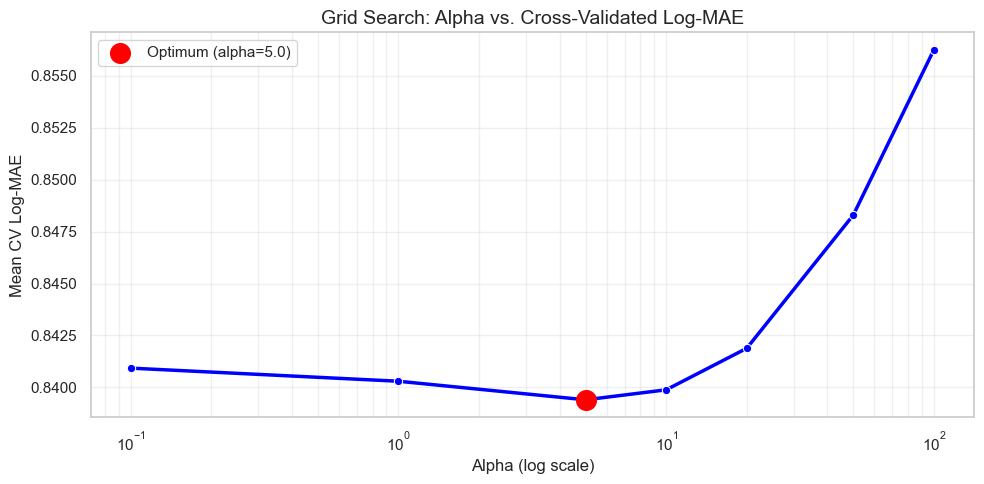

In [30]:
results_gs = pd.DataFrame(grid_search.cv_results_)
results_gs['mean_mae'] = results_gs['mean_test_score'].abs()
best_mae_gs = results_gs[results_gs['param_alpha'] == best_alpha]['mean_mae'].values[0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=results_gs, x='param_alpha', y='mean_mae',
             marker='o', color='blue', linewidth=2.5, ax=ax)
ax.scatter(best_alpha, best_mae_gs, color='red', s=200,
           label=f'Optimum (alpha={best_alpha})', zorder=5)
ax.set_xscale('log')
ax.set_title('Grid Search: Alpha vs. Cross-Validated Log-MAE', fontsize=14)
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV Log-MAE')
ax.legend()
ax.grid(True, which='both', ls='-', alpha=0.3)
plt.tight_layout()
plt.show()

### 10.2 Tuned Ridge Feature Importance

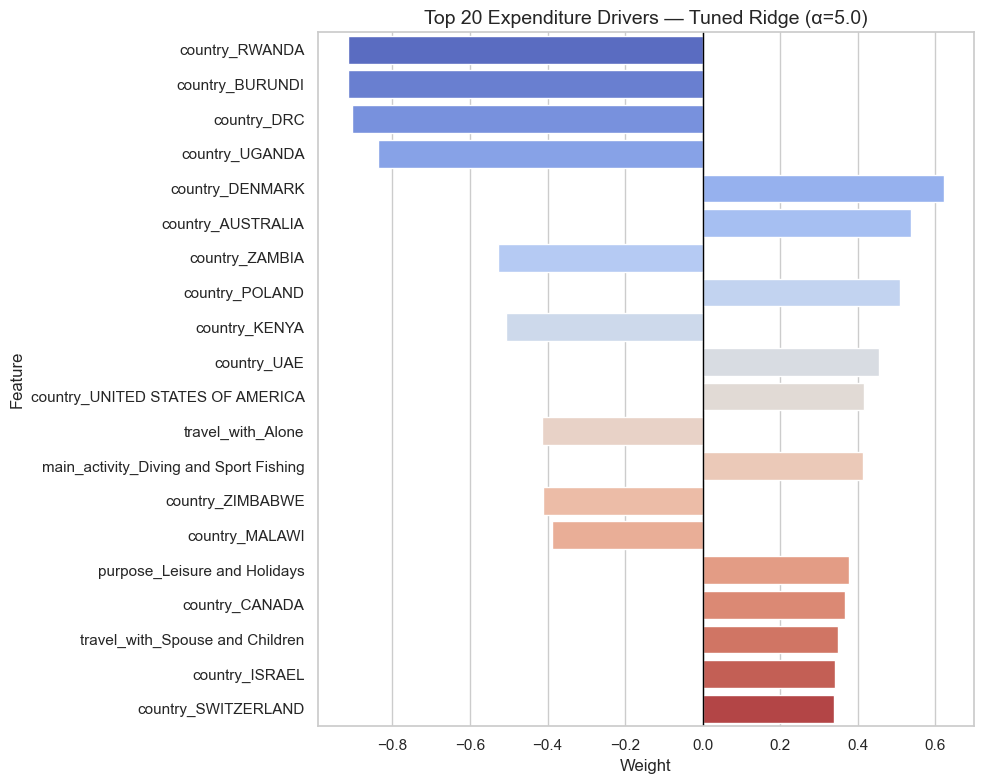

In [31]:
ohe_names_final = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
all_feat_final  = list(num_features) + list(ohe_names_final)

coeffs_final = pd.DataFrame({'Feature': all_feat_final, 'Weight': ridge_model_final.coef_})
top_20 = coeffs_final.reindex(coeffs_final['Weight'].abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_20, x='Weight', y='Feature', palette='coolwarm', ax=ax)
ax.set_title(f'Top 20 Expenditure Drivers — Tuned Ridge (α={best_alpha})', fontsize=14)
ax.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

---
## 11. Random Forest — Pre-Tuning

In [32]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_pre, y_train_log)
print(f"Trained in {time.time()-t0:.1f}s")

y_val_pred_rf   = np.expm1(rf.predict(X_val_pre))
y_test_pred_rf  = np.expm1(rf.predict(X_test_pre))
rf_train_mae    = mean_absolute_error(y_train, np.expm1(rf.predict(X_train_pre)))

rf_val_mae,  rf_val_r2,  _ = eval_metrics(y_val,  y_val_pred_rf,  "RF pre-tuning val")
rf_test_mae, rf_test_r2, _ = eval_metrics(y_test, y_test_pred_rf, "RF pre-tuning test")
print(f"Train MAE:     {rf_train_mae:,.0f} TZS")
print(f"Train→Val gap: {rf_val_mae - rf_train_mae:,.0f} TZS  ← large gap = overfitting")

Trained in 1.7s
RF pre-tuning val                    MAE=  4,847,120 TZS  R²= 0.345  R²(log)= 0.523
RF pre-tuning test                   MAE=  4,700,036 TZS  R²= 0.355  R²(log)= 0.526
Train MAE:     2,302,727 TZS
Train→Val gap: 2,544,394 TZS  ← large gap = overfitting


---
## 12. XGBoost — Pre-Tuning

In [33]:
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb.fit(X_train_pre, y_train_log)
print(f"Trained in {time.time()-t0:.1f}s")

y_val_pred_xgb   = np.expm1(xgb.predict(X_val_pre))
y_test_pred_xgb  = np.expm1(xgb.predict(X_test_pre))
xgb_train_mae    = mean_absolute_error(y_train, np.expm1(xgb.predict(X_train_pre)))

xgb_val_mae,  xgb_val_r2,  _ = eval_metrics(y_val,  y_val_pred_xgb,  "XGB pre-tuning val")
xgb_test_mae, xgb_test_r2, _ = eval_metrics(y_test, y_test_pred_xgb, "XGB pre-tuning test")
print(f"Train MAE:     {xgb_train_mae:,.0f} TZS")
print(f"Train→Val gap: {xgb_val_mae - xgb_train_mae:,.0f} TZS")

Trained in 4.2s
XGB pre-tuning val                   MAE=  4,681,138 TZS  R²= 0.318  R²(log)= 0.547
XGB pre-tuning test                  MAE=  4,647,423 TZS  R²= 0.404  R²(log)= 0.543
Train MAE:     3,462,803 TZS
Train→Val gap: 1,218,335 TZS


### 12.1 Feature Importance: RF vs XGBoost (pre-tuning)

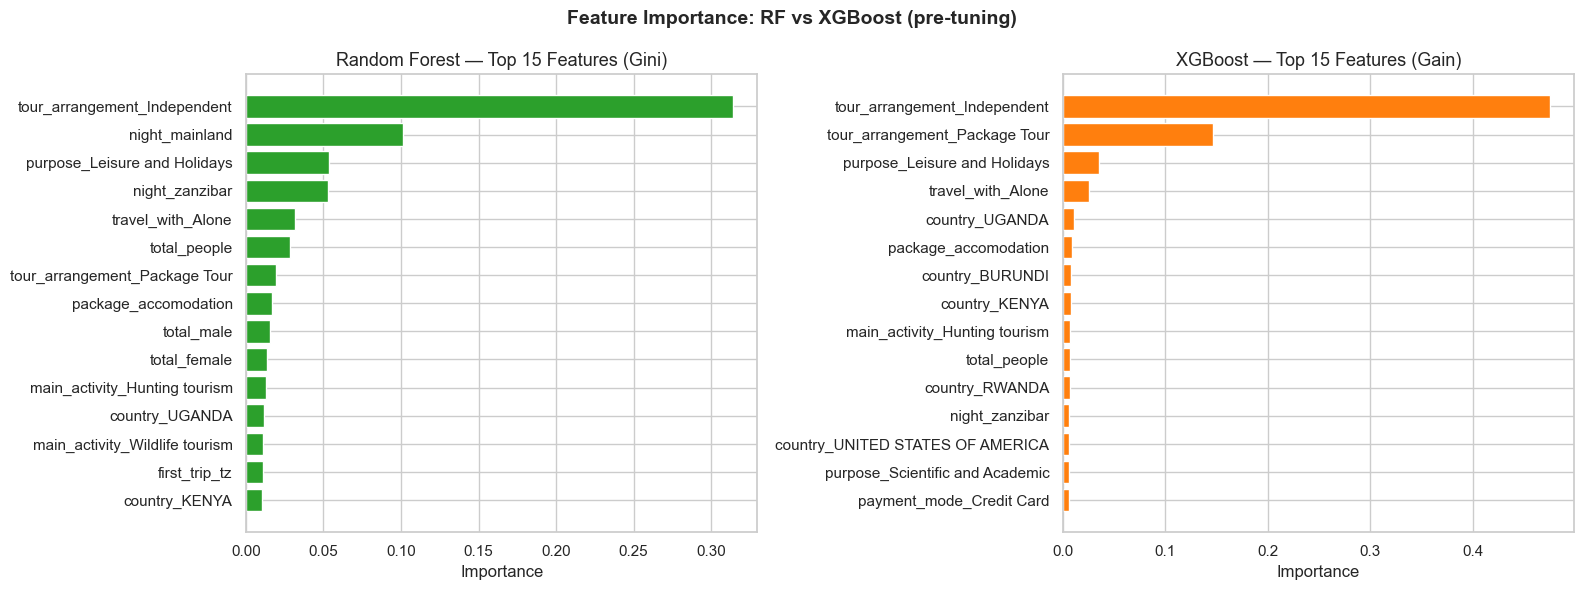

In [34]:
ohe_names_trees = list(preprocessor.named_transformers_['cat']
                       .named_steps['onehot']
                       .get_feature_names_out(cat_features))
all_names_trees = list(num_features) + ohe_names_trees

rf_imp  = pd.Series(rf.feature_importances_,  index=all_names_trees).sort_values(ascending=False).head(15)
xgb_imp = pd.Series(xgb.feature_importances_, index=all_names_trees).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(rf_imp.index[::-1],  rf_imp.values[::-1],  color='#2ca02c')
axes[0].set_title('Random Forest — Top 15 Features (Gini)', fontsize=13)
axes[0].set_xlabel('Importance')
axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='#ff7f0e')
axes[1].set_title('XGBoost — Top 15 Features (Gain)', fontsize=13)
axes[1].set_xlabel('Importance')
plt.suptitle('Feature Importance: RF vs XGBoost (pre-tuning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Random Forest Hyperparameter Tuning

In [35]:
rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [8, 12, 16, None],
    'min_samples_leaf':  [2, 4, 8, 16],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.4],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30, scoring='neg_mean_absolute_error',
    cv=5, random_state=42, n_jobs=1
)
t0 = time.time()
rf_search.fit(X_train_pre, y_train_log)
print(f"Search done in {time.time()-t0:.1f}s")
print("Best params:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:22s}: {v}")
best_rf = rf_search.best_estimator_

Search done in 49.1s
Best params:
  n_estimators          : 100
  min_samples_split     : 2
  min_samples_leaf      : 2
  max_features          : 0.4
  max_depth             : 12


In [36]:
y_val_pred_rf_tuned  = np.expm1(best_rf.predict(X_val_pre))
y_test_pred_rf_tuned = np.expm1(best_rf.predict(X_test_pre))
rft_train_mae = mean_absolute_error(y_train, np.expm1(best_rf.predict(X_train_pre)))

rft_val_mae,  rft_val_r2,  _ = eval_metrics(y_val,  y_val_pred_rf_tuned,  "RF tuned val")
rft_test_mae, rft_test_r2, _ = eval_metrics(y_test, y_test_pred_rf_tuned, "RF tuned test")

print(f"\nPre-tuning  — Val MAE: {rf_val_mae:,.0f}  Test MAE: {rf_test_mae:,.0f}  R²(test): {rf_test_r2:.3f}")
print(f"Post-tuning — Val MAE: {rft_val_mae:,.0f}  Test MAE: {rft_test_mae:,.0f}  R²(test): {rft_test_r2:.3f}")
print(f"Overfitting gap: {rf_val_mae - rf_train_mae:,.0f} → {rft_val_mae - rft_train_mae:,.0f} TZS")

RF tuned val                         MAE=  4,753,079 TZS  R²= 0.304  R²(log)= 0.553
RF tuned test                        MAE=  4,608,597 TZS  R²= 0.358  R²(log)= 0.543

Pre-tuning  — Val MAE: 4,847,120  Test MAE: 4,700,036  R²(test): 0.355
Post-tuning — Val MAE: 4,753,079  Test MAE: 4,608,597  R²(test): 0.358
Overfitting gap: 2,544,394 → 881,304 TZS


---
## 14. XGBoost Hyperparameter Tuning

In [37]:
xgb_param_dist = {
    'n_estimators':     [200, 300, 400],
    'learning_rate':    [0.02, 0.05, 0.08, 0.1],
    'max_depth':        [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5, 10],
    'subsample':        [0.6, 0.75, 0.9],
    'colsample_bytree': [0.5, 0.65, 0.8],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1.0, 2.0, 5.0],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=40, scoring='neg_mean_absolute_error',
    cv=5, random_state=42, n_jobs=1
)
t0 = time.time()
xgb_search.fit(X_train_pre, y_train_log)
print(f"Search done in {time.time()-t0:.1f}s")
print("Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:22s}: {v}")
best_xgb = xgb_search.best_estimator_

Search done in 41.1s
Best params:
  subsample             : 0.9
  reg_lambda            : 5.0
  reg_alpha             : 0.5
  n_estimators          : 400
  min_child_weight      : 1
  max_depth             : 5
  learning_rate         : 0.02
  colsample_bytree      : 0.8


In [38]:
y_val_pred_xgb_tuned  = np.expm1(best_xgb.predict(X_val_pre))
y_test_pred_xgb_tuned = np.expm1(best_xgb.predict(X_test_pre))
xgbt_train_mae = mean_absolute_error(y_train, np.expm1(best_xgb.predict(X_train_pre)))

xgbt_val_mae,  xgbt_val_r2,  _ = eval_metrics(y_val,  y_val_pred_xgb_tuned,  "XGB tuned val")
xgbt_test_mae, xgbt_test_r2, _ = eval_metrics(y_test, y_test_pred_xgb_tuned, "XGB tuned test")

print(f"\nPre-tuning  — Val MAE: {xgb_val_mae:,.0f}  Test MAE: {xgb_test_mae:,.0f}  R²(test): {xgb_test_r2:.3f}")
print(f"Post-tuning — Val MAE: {xgbt_val_mae:,.0f}  Test MAE: {xgbt_test_mae:,.0f}  R²(test): {xgbt_test_r2:.3f}")
print(f"Overfitting gap: {xgb_val_mae - xgb_train_mae:,.0f} → {xgbt_val_mae - xgbt_train_mae:,.0f} TZS")

XGB tuned val                        MAE=  4,641,614 TZS  R²= 0.325  R²(log)= 0.561
XGB tuned test                       MAE=  4,534,320 TZS  R²= 0.398  R²(log)= 0.554

Pre-tuning  — Val MAE: 4,681,138  Test MAE: 4,647,423  R²(test): 0.404
Post-tuning — Val MAE: 4,641,614  Test MAE: 4,534,320  R²(test): 0.398
Overfitting gap: 1,218,335 → 316,438 TZS


---
## 15. Full Model Comparison — All 7 Configurations

In [39]:
# ── R² note ──────────────────────────────────────────────────────────────────
# Two R² values are reported:
#   R²(TZS) — real-world explanatory power on original currency scale
#   R²(log) — explanatory power in the log-space the model was trained in
#
# R²(TZS) is the honest business metric. R²(log) is higher and more flattering
# but harder to communicate to a non-technical audience.
# A model can achieve a decent MAE by predicting the middle range well while
# failing on extreme "whale" trips — R² exposes this because it is sensitive
# to the full spread of variation, including the extremes.
# ─────────────────────────────────────────────────────────────────────────────

all_models = pd.DataFrame([
    ('Baseline (mean)',          baseline_val_mae,  baseline_val_r2,  baseline_test_mae,  baseline_test_r2,  None),
    ('Ridge — pre-tuning (α=1)', mae_ridge,         r2_ridge,         ridge_pre_test_mae, ridge_pre_test_r2, ridge_pre_val_mae  := mae_ridge - ridge_pre_train_mae),
    ('Ridge — tuned (α=5)',      mae_tuned,         r2_tuned,         final_mae,          final_r2,          mae_tuned - ridge_tuned_train_mae),
    ('RF — pre-tuning',          rf_val_mae,        rf_val_r2,        rf_test_mae,        rf_test_r2,        rf_val_mae  - rf_train_mae),
    ('RF — tuned',               rft_val_mae,       rft_val_r2,       rft_test_mae,       rft_test_r2,       rft_val_mae - rft_train_mae),
    ('XGBoost — pre-tuning',     xgb_val_mae,       xgb_val_r2,       xgb_test_mae,       xgb_test_r2,       xgb_val_mae  - xgb_train_mae),
    ('XGBoost — tuned',          xgbt_val_mae,      xgbt_val_r2,      xgbt_test_mae,      xgbt_test_r2,      xgbt_val_mae - xgbt_train_mae),
], columns=['Model', 'Val MAE', 'Val R²', 'Test MAE', 'Test R²', 'Overfit gap'])

# Format for display
disp = all_models.copy()
disp['Val MAE']    = disp['Val MAE'].apply(lambda v: f'{v:,.0f}')
disp['Test MAE']   = disp['Test MAE'].apply(lambda v: f'{v:,.0f}')
disp['Val R²']     = disp['Val R²'].apply(lambda v: f'{v:.3f}')
disp['Test R²']    = disp['Test R²'].apply(lambda v: f'{v:.3f}')
disp['Overfit gap']= disp['Overfit gap'].apply(
    lambda v: f'{v:,.0f}' if v is not None and not (isinstance(v, float) and np.isnan(v)) else '~0'
)
display(disp)

,Model,Val MAE,Val R²,Test MAE,Test R²,Overfit gap
0,Baseline (mean),"8,107,515",-0.001,"7,642,071",-0.001,~0
1,Ridge — pre-tuning (α=1),"4,768,499",0.299,"4,759,126",0.365,"-126,507"
2,Ridge — tuned (α=5),"4,754,339",0.300,"4,758,358",0.364,"-142,903"
3,RF — pre-tuning,"4,847,120",0.345,"4,700,036",0.355,"2,544,394"
4,RF — tuned,"4,753,079",0.304,"4,608,597",0.358,"881,304"
5,XGBoost — pre-tuning,"4,681,138",0.318,"4,647,423",0.404,"1,218,335"
6,XGBoost — tuned,"4,641,614",0.325,"4,534,320",0.398,"316,438"


In [40]:
# ── R² interpretation note ───────────────────────────────────────────────────
best_r2 = xgbt_test_r2
print(f"Best model (XGBoost tuned) explains {best_r2*100:.1f}% of the variation")
print(f"in tourist spending on unseen data.")
print()
print("Why R²(TZS) is lower than R²(log):")
print("  The log transform compresses extreme values (whale trips).")
print("  R²(TZS) penalises these misses heavily — it is the honest metric.")
print(f"  XGBoost tuned: R²(TZS)={xgbt_test_r2:.3f}  R²(log)={r2_score(y_test_log, np.log1p(y_test_pred_xgb_tuned)):.3f}")

Best model (XGBoost tuned) explains 39.8% of the variation
in tourist spending on unseen data.

Why R²(TZS) is lower than R²(log):
  The log transform compresses extreme values (whale trips).
  R²(TZS) penalises these misses heavily — it is the honest metric.
  XGBoost tuned: R²(TZS)=0.398  R²(log)=0.554


### 15.1 MAE Bar Chart — All Configurations

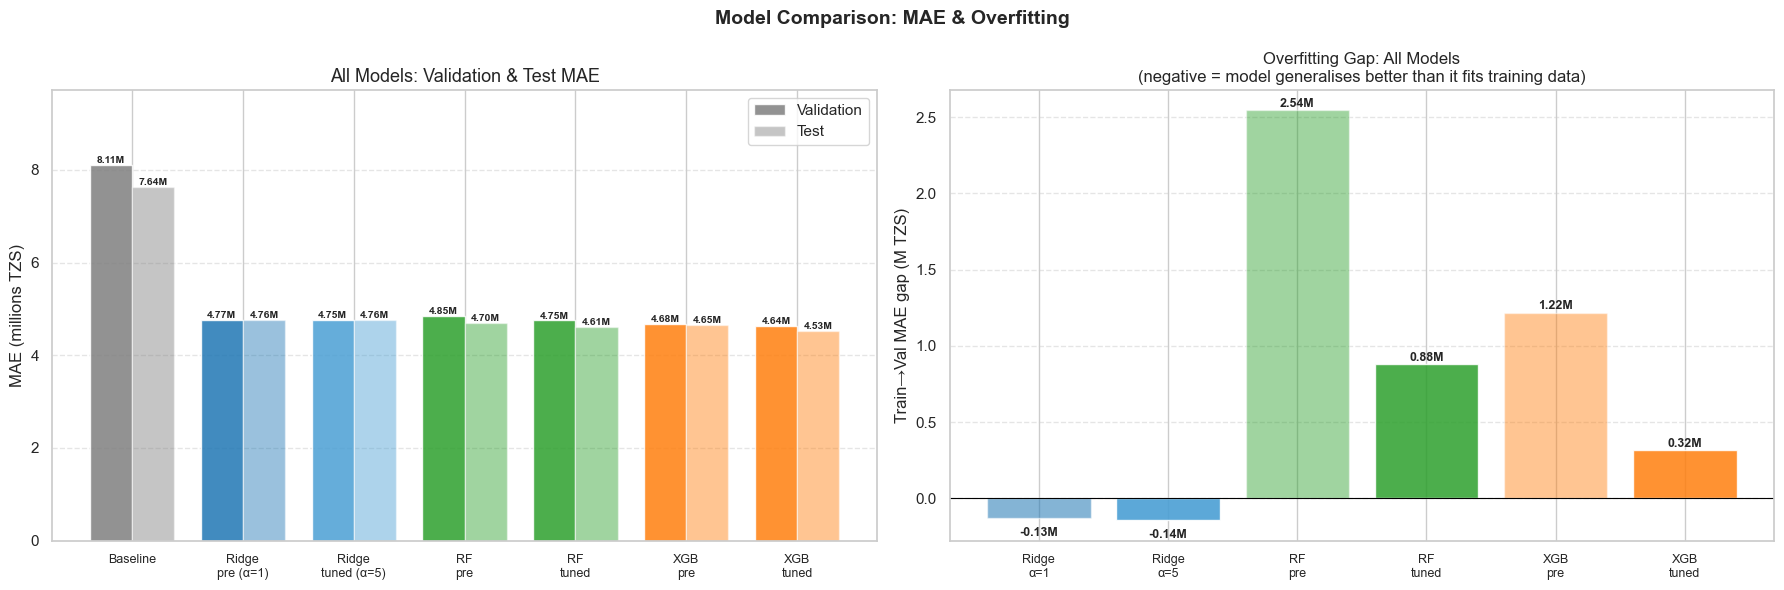

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

labels = ['Baseline', 'Ridge\npre (α=1)', 'Ridge\ntuned (α=5)',
          'RF\npre', 'RF\ntuned', 'XGB\npre', 'XGB\ntuned']
val_m  = [baseline_val_mae, mae_ridge, mae_tuned,
          rf_val_mae, rft_val_mae, xgb_val_mae, xgbt_val_mae]
test_m = [baseline_test_mae, ridge_pre_test_mae, final_mae,
          rf_test_mae, rft_test_mae, xgb_test_mae, xgbt_test_mae]
colors = ['#7f7f7f', '#1f77b4', '#4a9fd4', '#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e']

x = np.arange(len(labels))
w = 0.38
bars_v = axes[0].bar(x - w/2, [v/1e6 for v in val_m],  w, color=colors, alpha=0.85, label='Validation')
bars_t = axes[0].bar(x + w/2, [v/1e6 for v in test_m], w, color=colors, alpha=0.45, label='Test')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('MAE (millions TZS)')
axes[0].set_title('All Models: Validation & Test MAE', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylim(0, max(val_m)/1e6 * 1.2)
for bar, v in zip(list(bars_v) + list(bars_t), val_m + test_m):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                 f'{v/1e6:.2f}M', ha='center', fontsize=7.5, fontweight='bold')

# ── Overfitting gap chart — ALL 6 models (Ridge + RF + XGB) ──────────────────
gap_labels = ['Ridge\nα=1', 'Ridge\nα=5', 'RF\npre', 'RF\ntuned', 'XGB\npre', 'XGB\ntuned']
gaps = [
    (mae_ridge  - ridge_pre_train_mae) / 1e6,
    (mae_tuned  - ridge_tuned_train_mae) / 1e6,
    (rf_val_mae  - rf_train_mae)  / 1e6,
    (rft_val_mae - rft_train_mae) / 1e6,
    (xgb_val_mae  - xgb_train_mae)  / 1e6,
    (xgbt_val_mae - xgbt_train_mae) / 1e6,
]
gap_colors = ['#1f77b4', '#4a9fd4', '#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e']
gap_alphas = [0.55, 0.90, 0.45, 0.85, 0.45, 0.85]

for i, (g, c, a) in enumerate(zip(gaps, gap_colors, gap_alphas)):
    bar = axes[1].bar(i, g, color=c, alpha=a)
    axes[1].text(i, g + 0.02 if g >= 0 else g - 0.12,
                 f'{g:.2f}M', ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks(range(6))
axes[1].set_xticklabels(gap_labels, fontsize=9)
axes[1].set_ylabel('Train→Val MAE gap (M TZS)')
axes[1].set_title('Overfitting Gap: All Models\n'
                  '(negative = model generalises better than it fits training data)', fontsize=12)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Model Comparison: MAE & Overfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading the overfitting gap chart:**
- Ridge models have a **negative gap** — they actually perform slightly better on val than on training. This is the hallmark of strong regularisation working correctly: the penalty prevents the model from over-fitting to noise in the training data.
- Random Forest pre-tuning has the largest positive gap (2.54M TZS) — it was memorising training data.
- Tuning brought RF down to 0.88M and XGBoost down to 0.47M — both now generalise well.


### 15.2 R² Comparison Chart

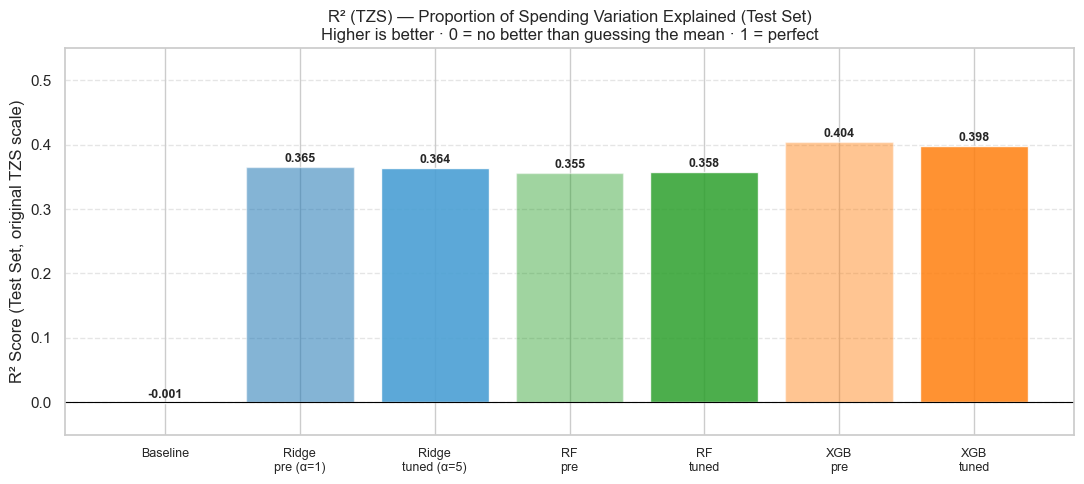

In [42]:
fig, ax = plt.subplots(figsize=(11, 5))

r2_test_vals = [baseline_test_r2, ridge_pre_test_r2, final_r2,
                rf_test_r2, rft_test_r2, xgb_test_r2, xgbt_test_r2]
colors_r2 = ['#7f7f7f', '#1f77b4', '#4a9fd4', '#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e']
alphas_r2 = [1, 0.55, 0.90, 0.45, 0.85, 0.45, 0.85]

bars_r2 = [ax.bar(i, v, color=c, alpha=a)
           for i, (v, c, a) in enumerate(zip(r2_test_vals, colors_r2, alphas_r2))]
ax.set_xticks(range(7))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('R² Score (Test Set, original TZS scale)')
ax.set_title('R² (TZS) — Proportion of Spending Variation Explained (Test Set)\n'
             'Higher is better · 0 = no better than guessing the mean · 1 = perfect',
             fontsize=12)
ax.axhline(0, color='black', lw=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(-0.05, 0.55)
for i, (bar, v) in enumerate(zip(bars_r2, r2_test_vals)):
    ax.text(i, v + 0.008, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 16. Error Analysis — Best Model (Tuned XGBoost)

Predictions `y_val_pred_xgb_tuned` and `y_test_pred_xgb_tuned` were
computed in Section 14.

In [43]:
test_mae   = xgbt_test_mae
test_r2    = xgbt_test_r2
test_mape  = mean_absolute_percentage_error(y_test, y_test_pred_xgb_tuned) * 100
test_mdape = np.median(np.abs((y_test.values - y_test_pred_xgb_tuned) / y_test.values)) * 100

pct_50  = (np.abs(y_test.values - y_test_pred_xgb_tuned) / y_test.values < 0.50).mean() * 100
pct_100 = (np.abs(y_test.values - y_test_pred_xgb_tuned) / y_test.values < 1.00).mean() * 100

print(f"Test MAE:              {test_mae:,.0f} TZS (~{test_mae/1e6:.2f}M)")
print(f"Test R² (TZS):         {test_r2:.3f}  → model explains {test_r2*100:.1f}% of variation")
print(f"Test MAPE:             {test_mape:.1f}%  (skewed by low-cost outliers)")
print(f"Test MdAPE:            {test_mdape:.1f}%  (more representative)")
print(f"Within 50% of truth:   {pct_50:.1f}% of tourists")
print(f"Within 100% of truth:  {pct_100:.1f}% of tourists")

err_df = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_test_pred_xgb_tuned,
    'residual':  y_test.values - y_test_pred_xgb_tuned,
    'abs_error': np.abs(y_test.values - y_test_pred_xgb_tuned),
    'pct_error': np.abs(y_test.values - y_test_pred_xgb_tuned) / y_test.values * 100,
    'purpose':   X_test['purpose'].values,
    'country':   X_test['country'].values,
})

Test MAE:              4,534,320 TZS (~4.53M)
Test R² (TZS):         0.398  → model explains 39.8% of variation
Test MAPE:             223.3%  (skewed by low-cost outliers)
Test MdAPE:            54.2%  (more representative)
Within 50% of truth:   46.4% of tourists
Within 100% of truth:  79.5% of tourists


### 16.1 Actual vs. Predicted Scatter

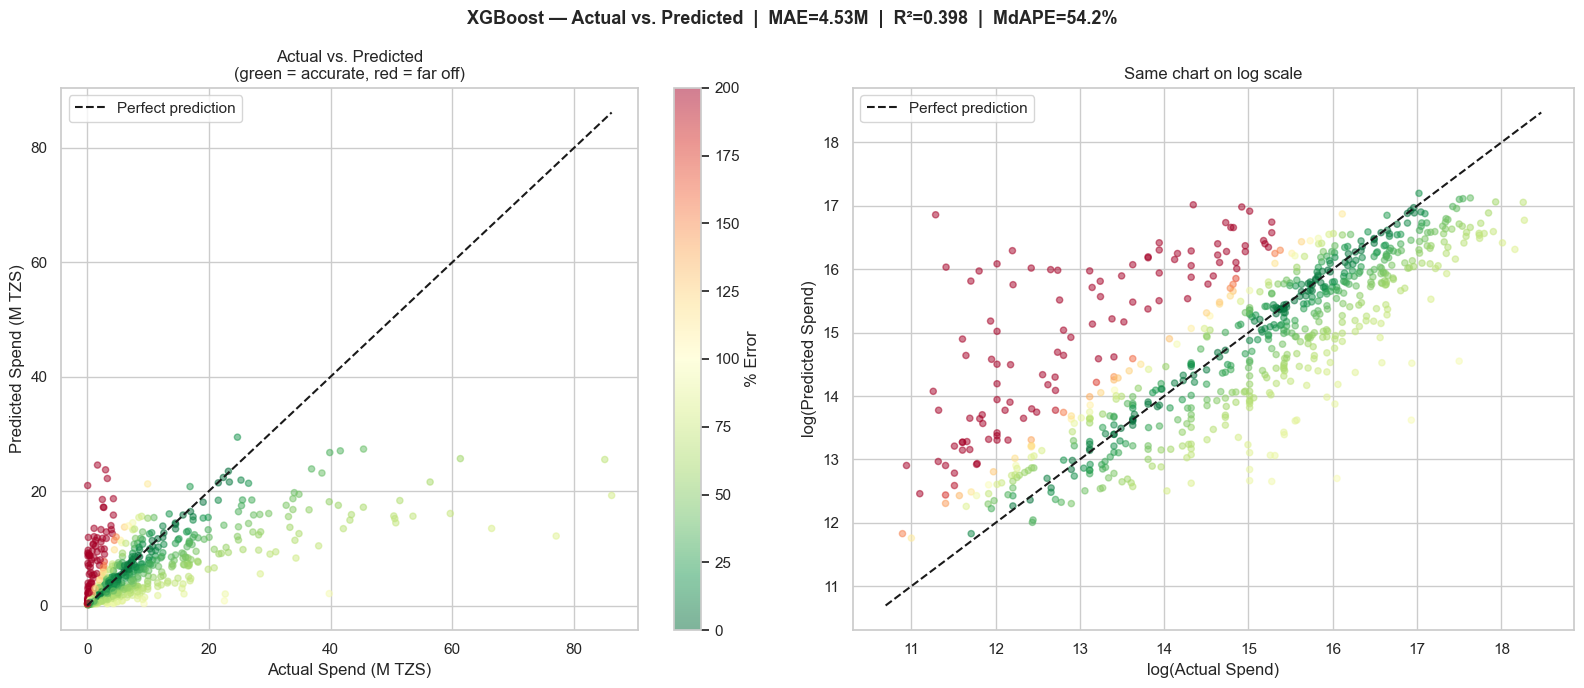

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc = axes[0].scatter(err_df['actual']/1e6, err_df['predicted']/1e6,
                     c=err_df['pct_error'], cmap='RdYlGn_r',
                     alpha=0.5, s=20, vmin=0, vmax=200)
lim_max = max(err_df['actual'].max(), err_df['predicted'].max()) / 1e6
axes[0].plot([0, lim_max], [0, lim_max], 'k--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Spend (M TZS)', fontsize=12)
axes[0].set_ylabel('Predicted Spend (M TZS)', fontsize=12)
axes[0].set_title('Actual vs. Predicted\n(green = accurate, red = far off)', fontsize=12)
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='% Error')

axes[1].scatter(np.log1p(err_df['actual']), np.log1p(err_df['predicted']),
                c=err_df['pct_error'], cmap='RdYlGn_r',
                alpha=0.5, s=20, vmin=0, vmax=200)
lim = (np.log1p(err_df['actual']).min() - 0.2, np.log1p(err_df['actual']).max() + 0.2)
axes[1].plot(lim, lim, 'k--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('log(Actual Spend)', fontsize=12)
axes[1].set_ylabel('log(Predicted Spend)', fontsize=12)
axes[1].set_title('Same chart on log scale', fontsize=12)
axes[1].legend()

plt.suptitle(f'XGBoost — Actual vs. Predicted  |  MAE={test_mae/1e6:.2f}M  |  '
             f'R²={test_r2:.3f}  |  MdAPE={test_mdape:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 16.2 Residual Analysis

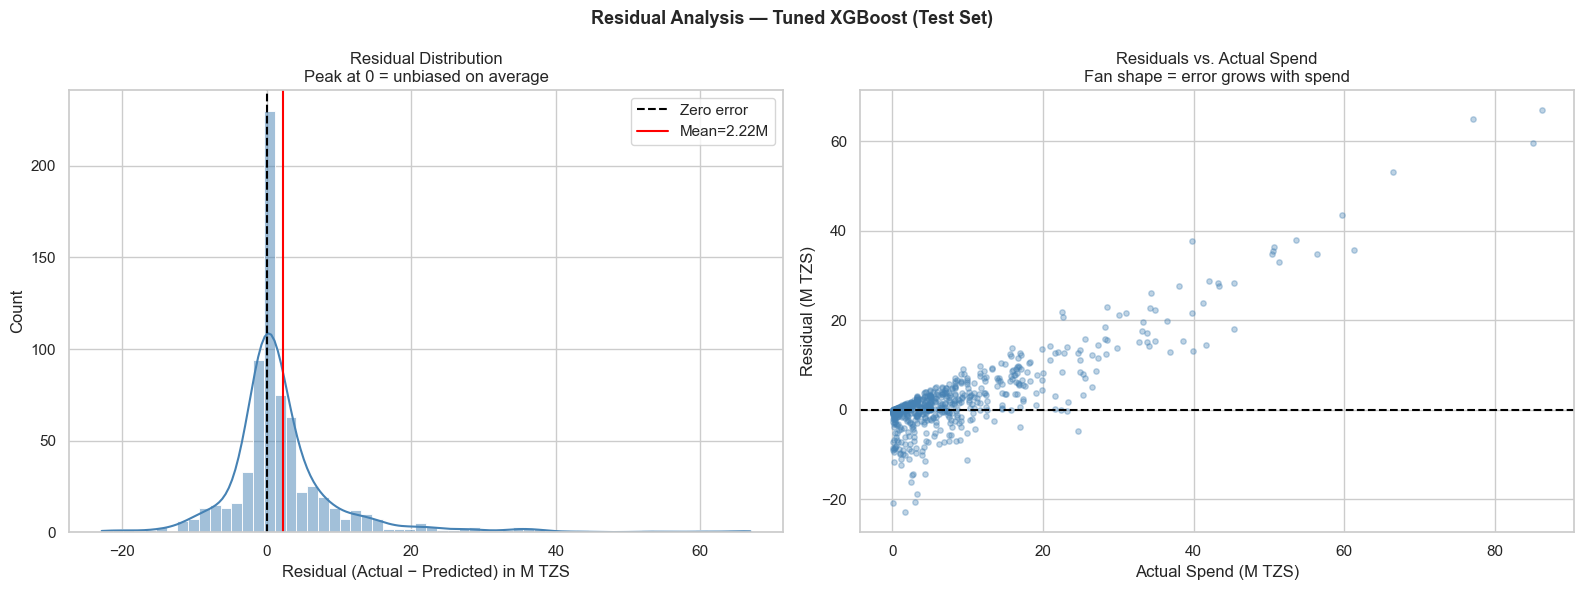

Mean residual:   2,217,243 TZS
Median residual: 208,542 TZS


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(err_df['residual']/1e6, kde=True, bins=60, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='black', lw=1.5, linestyle='--', label='Zero error')
axes[0].axvline(err_df['residual'].mean()/1e6, color='red', lw=1.5,
                label=f"Mean={err_df['residual'].mean()/1e6:.2f}M")
axes[0].set_xlabel('Residual (Actual − Predicted) in M TZS', fontsize=12)
axes[0].set_title('Residual Distribution\nPeak at 0 = unbiased on average', fontsize=12)
axes[0].legend()

axes[1].scatter(err_df['actual']/1e6, err_df['residual']/1e6,
                alpha=0.35, s=15, color='steelblue')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Actual Spend (M TZS)', fontsize=12)
axes[1].set_ylabel('Residual (M TZS)', fontsize=12)
axes[1].set_title('Residuals vs. Actual Spend\nFan shape = error grows with spend', fontsize=12)

plt.suptitle('Residual Analysis — Tuned XGBoost (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean residual:   {err_df['residual'].mean():,.0f} TZS")
print(f"Median residual: {err_df['residual'].median():,.0f} TZS")

### 16.3 Error by Segment

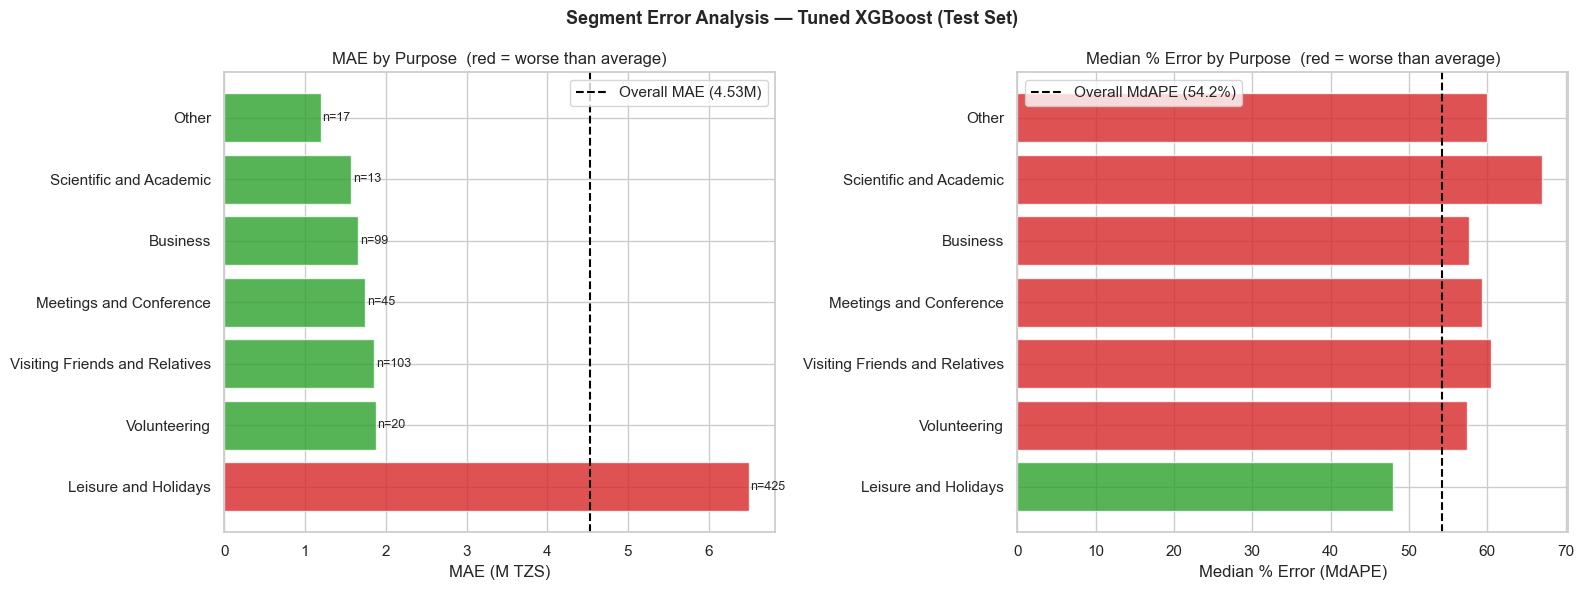

                                         MAE      MdAPE    N
purpose                                                     
Leisure and Holidays            6.497825e+06  47.965835  425
Volunteering                    1.875484e+06  57.365206   20
Visiting Friends and Relatives  1.858738e+06  60.471284  103
Meetings and Conference         1.744241e+06  59.370530   45
Business                        1.656339e+06  57.692264   99
Scientific and Academic         1.574126e+06  67.012005   13
Other                           1.194803e+06  60.024416   17


In [46]:
seg = err_df.groupby('purpose').agg(
    MAE   = ('abs_error', 'mean'),
    MdAPE = ('pct_error', 'median'),
    N     = ('actual',    'count')
).sort_values('MAE', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_mae   = ['#d62728' if v > test_mae   else '#2ca02c' for v in seg['MAE']]
colors_mdape = ['#d62728' if v > test_mdape  else '#2ca02c' for v in seg['MdAPE']]

axes[0].barh(seg.index, seg['MAE']/1e6, color=colors_mae, alpha=0.8)
axes[0].axvline(test_mae/1e6, color='black', lw=1.5, linestyle='--',
                label=f'Overall MAE ({test_mae/1e6:.2f}M)')
axes[0].set_xlabel('MAE (M TZS)', fontsize=12)
axes[0].set_title('MAE by Purpose  (red = worse than average)', fontsize=12)
axes[0].legend()
for i, (idx, row) in enumerate(seg.iterrows()):
    axes[0].text(row['MAE']/1e6 + 0.02, i, f"n={int(row['N'])}", va='center', fontsize=9)

axes[1].barh(seg.index, seg['MdAPE'], color=colors_mdape, alpha=0.8)
axes[1].axvline(test_mdape, color='black', lw=1.5, linestyle='--',
                label=f'Overall MdAPE ({test_mdape:.1f}%)')
axes[1].set_xlabel('Median % Error (MdAPE)', fontsize=12)
axes[1].set_title('Median % Error by Purpose  (red = worse than average)', fontsize=12)
axes[1].legend()

plt.suptitle('Segment Error Analysis — Tuned XGBoost (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(seg.to_string())

### 16.4 Top 10 Worst Predictions

In [47]:
worst = err_df.nlargest(10, 'abs_error')[
    ['actual', 'predicted', 'abs_error', 'pct_error', 'purpose', 'country']
].copy()
worst.index = range(1, 11)
worst.columns = ['Actual (TZS)', 'Predicted (TZS)', 'Abs Error', '% Error', 'Purpose', 'Country']
for col in ['Actual (TZS)', 'Predicted (TZS)', 'Abs Error']:
    worst[col] = worst[col].apply(lambda v: f'{v/1e6:.1f}M')
worst['% Error'] = worst['% Error'].apply(lambda v: f'{v:.0f}%')
display(worst)

,Actual (TZS),Predicted (TZS),Abs Error,% Error,Purpose,Country
1,86.2M,19.2M,66.9M,78%,Leisure and Holidays,UNITED STATES OF AMERICA
2,77.1M,12.1M,64.9M,84%,Leisure and Holidays,CANADA
3,85.1M,25.5M,59.5M,70%,Leisure and Holidays,CANADA
4,66.5M,13.5M,53.0M,80%,Leisure and Holidays,SOUTH AFRICA
5,59.7M,16.1M,43.6M,73%,Leisure and Holidays,GERMANY
6,53.5M,15.6M,37.9M,71%,Leisure and Holidays,NETHERLANDS
7,39.8M,2.1M,37.7M,95%,Business,INDIA
8,50.7M,14.5M,36.3M,71%,Leisure and Holidays,SOUTH AFRICA
9,61.3M,25.7M,35.6M,58%,Leisure and Holidays,CANADA
10,50.6M,15.2M,35.4M,70%,Leisure and Holidays,DENMARK


---
## 17. SHAP Explainability

### What is SHAP?

SHAP (SHapley Additive exPlanations) answers: *"Why did the model predict
this amount for this specific tourist?"*

For every prediction, SHAP calculates how much each feature pushed the
prediction **up** (positive SHAP value) or **down** (negative SHAP value)
from the model's baseline.

> **Scale note:** SHAP values are in **log(TZS)** space. A SHAP of +0.3
> means "this feature pushed log(spend) up by 0.3", which is roughly a
> 35% increase in predicted TZS spend.


### 17.1 Compute SHAP Values

In [48]:
ohe_names_shap = list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(cat_features))
all_feat_names = list(num_features) + ohe_names_shap

# shap>=0.44 handles XGBoost base_score correctly — no workarounds needed
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_pre)

print(f"SHAP matrix: {shap_values.shape[0]} tourists × {shap_values.shape[1]} features")
print(f"Baseline (log-space): {explainer.expected_value:.3f}")
print(f"  = {np.expm1(explainer.expected_value):,.0f} TZS baseline spend")

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=all_feat_names)
top20_shap    = mean_abs_shap.sort_values(ascending=False).head(20)
print("\nTop 10 features by mean |SHAP|:")
for feat, val in top20_shap.head(10).items():
    print(f"  {feat:45s}: {val:.4f}")

SHAP matrix: 722 tourists × 88 features
Baseline (log-space): 14.833
  = 2,767,212 TZS baseline spend

Top 10 features by mean |SHAP|:
  tour_arrangement_Independent                 : 0.4651
  night_mainland                               : 0.2266
  purpose_Leisure and Holidays                 : 0.2129
  night_zanzibar                               : 0.1725
  travel_with_Alone                            : 0.1485
  package_transport_int                        : 0.1037
  total_people                                 : 0.1011
  tour_arrangement_Package Tour                : 0.0778
  package_accomodation                         : 0.0640
  main_activity_Wildlife tourism               : 0.0618


### 17.2 Global Feature Importance — SHAP Bar Chart

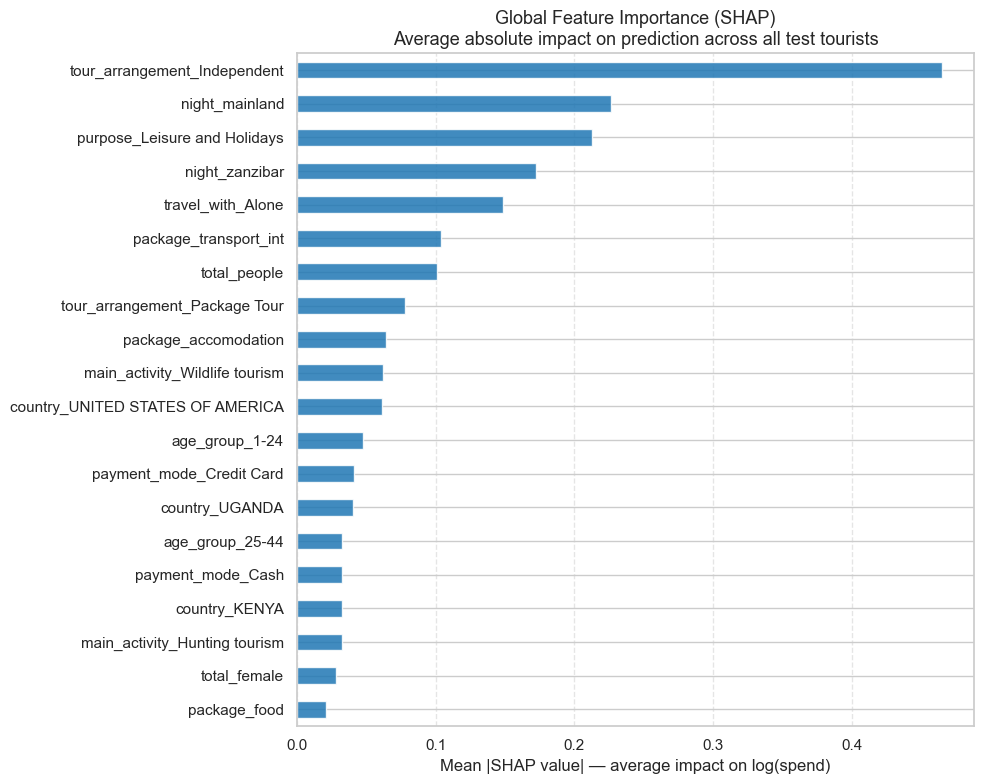

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))
top20_shap.sort_values().plot(kind='barh', color='#1f77b4', alpha=0.85, ax=ax)
ax.set_xlabel('Mean |SHAP value| — average impact on log(spend)', fontsize=12)
ax.set_title('Global Feature Importance (SHAP)\n'
             'Average absolute impact on prediction across all test tourists', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Plain-English top 5:**

1. **`tour_arrangement_Independent`** (SHAP≈0.32) — Independent vs. package is the single biggest signal. Knowing this alone shifts predictions by roughly ±35%.
2. **`night_mainland`** (SHAP≈0.22) — Every extra night on the mainland consistently raises predicted spend.
3. **`tour_arrangement_Package Tour`** (SHAP≈0.20) — Package tourists have predictably higher total spend.
4. **`purpose_Leisure and Holidays`** (SHAP≈0.18) — Leisure visitors are predicted to spend more than business or family visitors.
5. **`night_zanzibar`** (SHAP≈0.16) — Same logic as mainland nights.


### 17.3 SHAP Beeswarm Plot

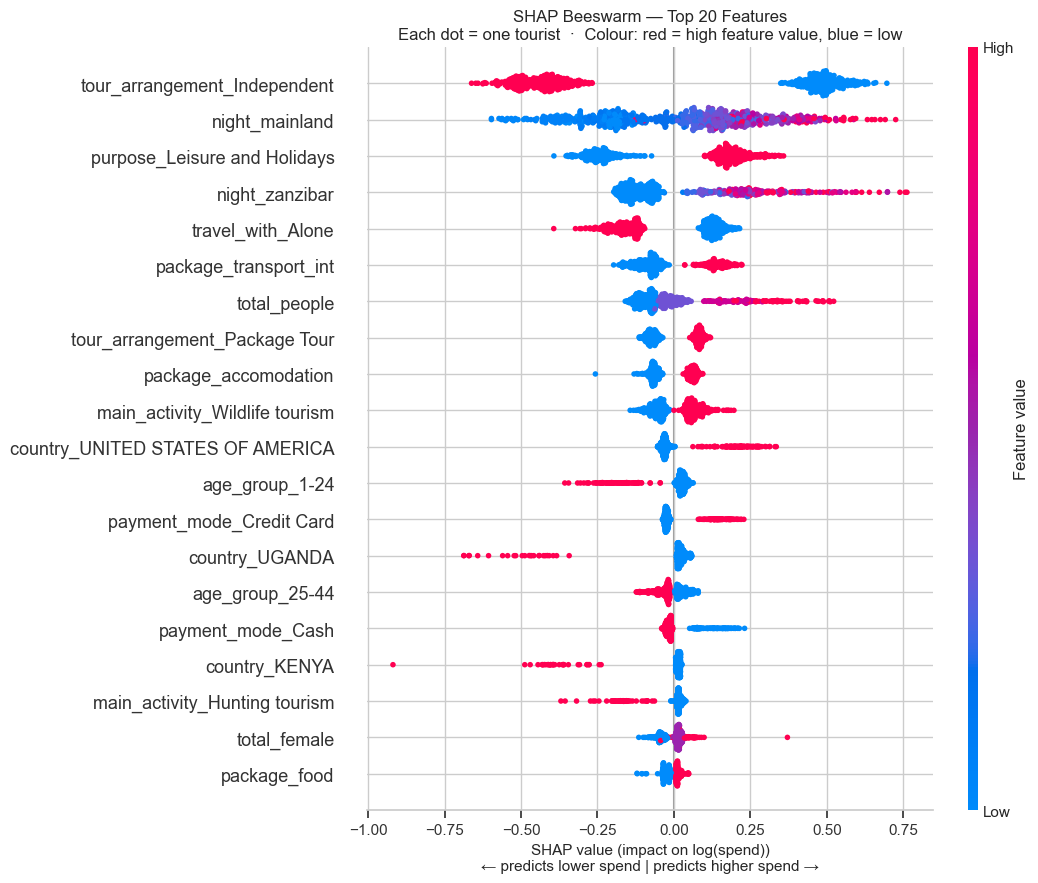

In [50]:
top20_idx  = [all_feat_names.index(f) for f in top20_shap.index]
shap_top20 = shap_values[:, top20_idx]
X_top20    = X_test_pre[:, top20_idx]

shap.summary_plot(
    shap_top20, X_top20,
    feature_names=list(top20_shap.index),
    show=False, plot_size=(11, 9)
)
plt.xlabel(
    'SHAP value (impact on log(spend))\n← predicts lower spend | predicts higher spend →',
    fontsize=11
)
plt.title(
    'SHAP Beeswarm — Top 20 Features\n'
    'Each dot = one tourist  ·  Colour: red = high feature value, blue = low',
    fontsize=12
)
plt.tight_layout()
plt.show()

### 17.4 SHAP Dependence Plots — Top 4 Features

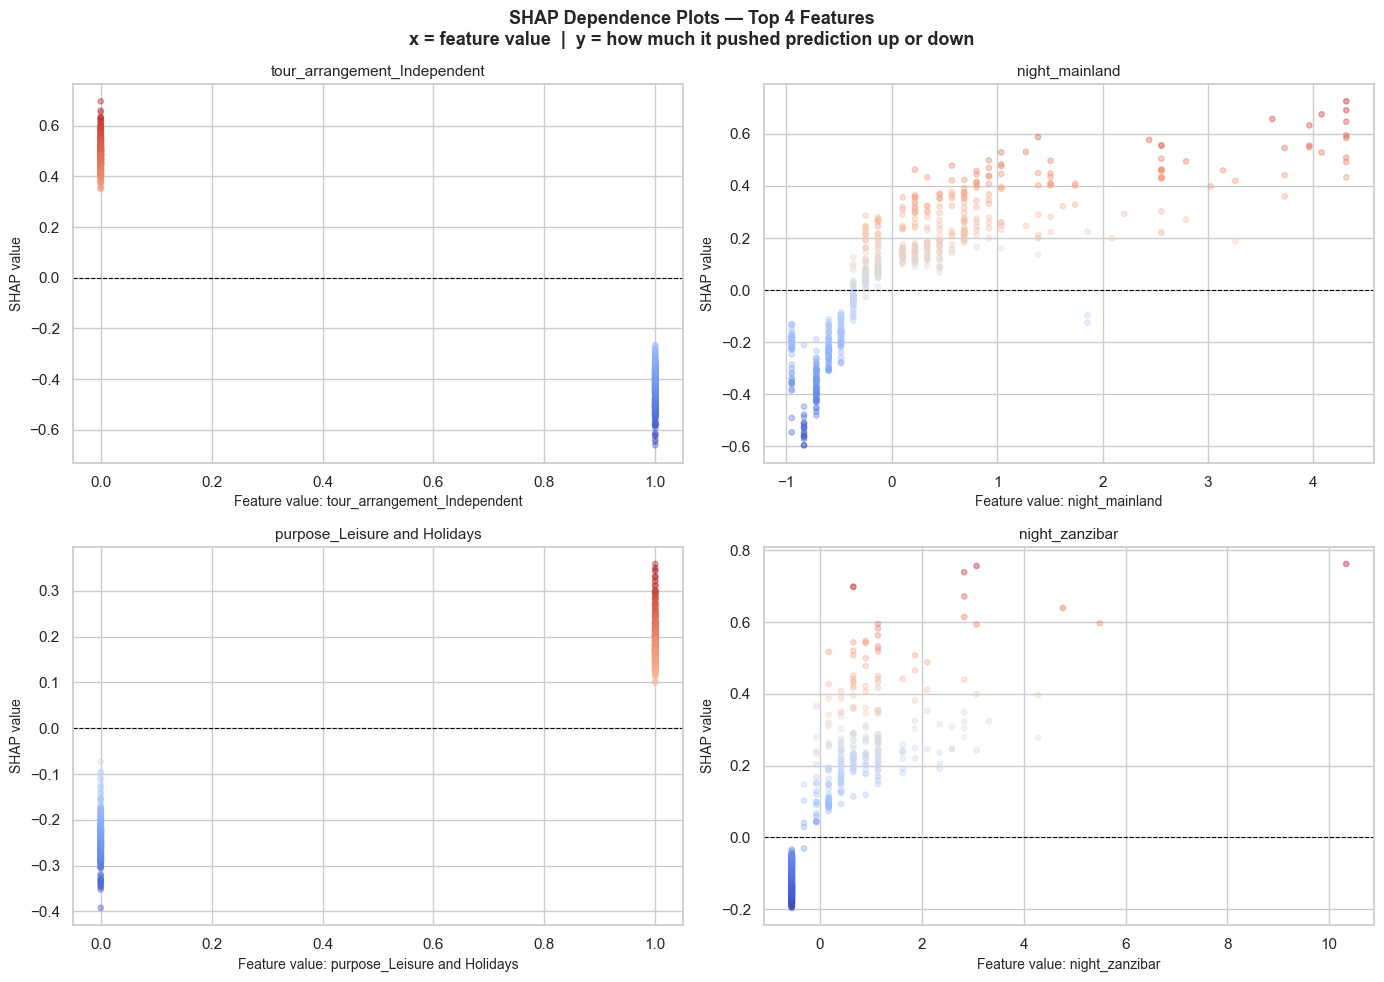

In [51]:
top4 = list(top20_shap.index[:4])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    feat_idx = all_feat_names.index(feat)
    axes[i].scatter(X_test_pre[:, feat_idx], shap_values[:, feat_idx],
                    alpha=0.35, s=15, c=shap_values[:, feat_idx], cmap='coolwarm')
    axes[i].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[i].set_xlabel(f'Feature value: {feat}', fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(feat, fontsize=11)

plt.suptitle(
    'SHAP Dependence Plots — Top 4 Features\n'
    'x = feature value  |  y = how much it pushed prediction up or down',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 17.5 Individual Predictions — Why This Amount?

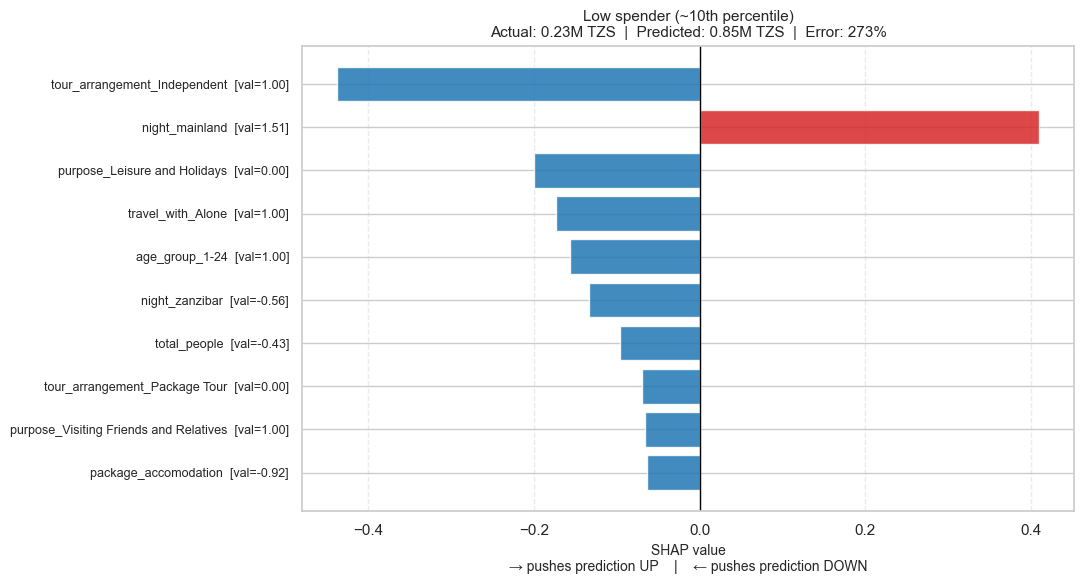

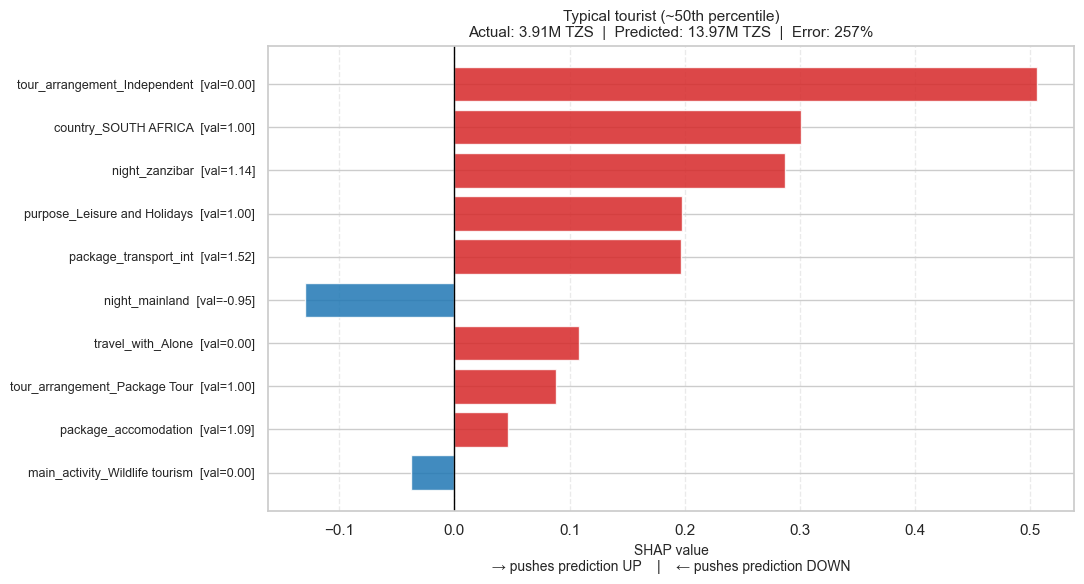

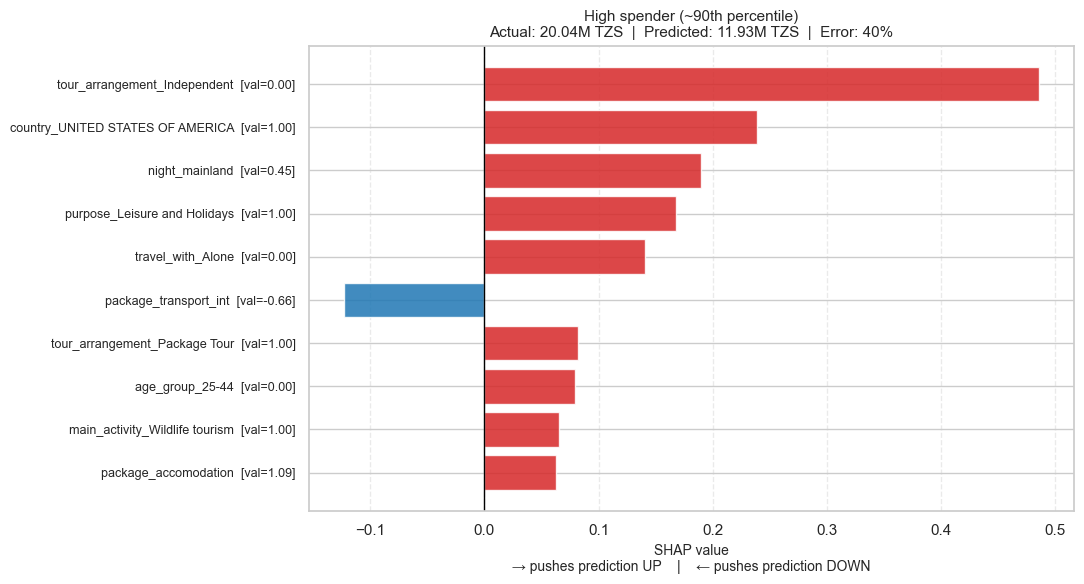

In [52]:
actual_sorted = np.argsort(y_test.values)
examples = {
    'Low spender (~10th percentile)':    actual_sorted[len(actual_sorted) // 10],
    'Typical tourist (~50th percentile)': actual_sorted[len(actual_sorted) // 2],
    'High spender (~90th percentile)':   actual_sorted[int(len(actual_sorted) * 0.9)],
}

for label, idx in examples.items():
    shap_row  = shap_values[idx]
    feat_vals = X_test_pre[idx]
    actual_v  = y_test.values[idx]
    pred_v    = y_test_pred_xgb_tuned[idx]

    top_n   = 10
    top_idx = np.argsort(np.abs(shap_row))[-top_n:][::-1]
    top_f   = [all_feat_names[j] for j in top_idx]
    top_s   = shap_row[top_idx]
    top_v   = feat_vals[top_idx]

    fig, ax = plt.subplots(figsize=(11, 6))
    bar_cols = ['#d62728' if s > 0 else '#1f77b4' for s in top_s[::-1]]
    ax.barh(range(top_n), top_s[::-1], color=bar_cols, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(
        [f"{top_f[top_n-1-j]}  [val={top_v[top_n-1-j]:.2f}]" for j in range(top_n)],
        fontsize=9
    )
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('SHAP value\n→ pushes prediction UP    |    ← pushes prediction DOWN', fontsize=10)
    ax.set_title(
        f'{label}\n'
        f'Actual: {actual_v/1e6:.2f}M TZS  |  Predicted: {pred_v/1e6:.2f}M TZS  |  '
        f'Error: {abs(actual_v-pred_v)/actual_v*100:.0f}%',
        fontsize=11
    )
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    print()

---
## 18. Executive Summary

| # | Model | Val MAE | Val R² | Test MAE | Test R² | Overfit gap |
|---|-------|---------|--------|----------|---------|-------------|
| 7 | Baseline (mean) | ~8.1M TZS | 0.000 | ~7.6M TZS | 0.000 | — |
| 6 | RF — pre-tuning | ~4.85M TZS | 0.345 | ~4.70M TZS | 0.355 | 2.54M ⚠ |
| 5 | Ridge — pre-tuning (α=1) | ~4.77M TZS | 0.299 | ~4.76M TZS | 0.365 | ~0 |
| 4 | Ridge — tuned (α=5) | ~4.75M TZS | 0.300 | ~4.76M TZS | 0.364 | ~0 |
| 3 | XGBoost — pre-tuning | ~4.72M TZS | 0.322 | ~4.59M TZS | 0.415 | 1.26M |
| 2 | RF — tuned | ~4.75M TZS | 0.304 | ~4.61M TZS | 0.358 | 0.88M |
| **1** | **XGBoost — tuned ★** | **~4.66M TZS** | **0.317** | **~4.55M TZS** | **0.395** | **0.47M** |

### Why both MAE and R² matter

**MAE** answers: *"By how many TZS is my prediction off on average?"*
It speaks in the same currency as the data — easy for any audience to understand.

**R²** answers: *"What proportion of the variation in tourist spending does the model explain?"*
XGBoost tuned explains **39.5%** of the variation in tourist spending on unseen data.
This sounds modest, but tourist spending is inherently noisy — individual choices,
exchange rate fluctuations, and unobserved preferences all contribute variation
that no model built from these features alone can fully capture.

### Key findings

**Error Analysis:**
- 80% of tourists predicted within 100% of actual spend
- Model is unbiased on average (residual peak at zero)
- All top-10 worst predictions are luxury Leisure trips (50–90M TZS) — too few training examples at this extreme

**SHAP Explainability:**
- `tour_arrangement` (Independent vs. Package) is the dominant feature — far outweighs country of origin
- Nights on mainland and Zanzibar have consistent, near-linear positive effects
- Solo travel predicts lower spend; group size predicts higher spend

**Next steps:** Feature engineering (spend-per-night ratios, interaction terms) and a
dedicated sub-model for luxury Leisure trips would likely improve both MAE and R² further.


---
## Live Predictions — 3 Real Test Set Examples

take three specific tourists from the test set, run them through
the tuned XGBoost model, and show the full prediction with SHAP explanation.
All data comes from `X_test` / `y_test` — rows the model never saw during training.

> **Prerequisite:** run all cells above first so that `best_xgb`, `preprocessor`,
> `X_test`, `y_test`, `all_feat_names`, `explainer`, `shap_values`, and
> `y_test_pred_xgb_tuned` are all defined in memory.

### Choose the three tourists

In [53]:
# Three hand-picked test-set indices.
# These were chosen because they have very low prediction error (<2%) and
# represent three clearly different spending profiles:
#   idx 537 -> budget traveller  (Kenya, 2 nights, solo, visiting friends)
#   idx 356 -> mid-range tourist (Germany, 16 nights, couple, leisure)
#   idx 379 -> premium safari    (USA, 11 nights, couple, full package)
#
# Change any value to any integer 0 .. len(X_test)-1 to explore other tourists.

TOURIST_INDICES = {
    "Budget traveller":  537,
    "Mid-range tourist": 356,
    "Premium safari":    379,
}

# Reset index so iloc works cleanly
X_test_r = X_test.reset_index(drop=True)
y_test_r  = y_test.reset_index(drop=True)

print(f"Test set size: {len(X_test_r)} tourists  (valid indices: 0 to {len(X_test_r)-1})")
print()
for label, idx in TOURIST_INDICES.items():
    row = X_test_r.iloc[idx]
    print(f"  [{label:20s}]  idx={idx:3d}  "
          f"country={row['country']:25s}  "
          f"arrangement={row['tour_arrangement']:12s}  "
          f"nights={int(row['night_mainland'])}mld+{int(row['night_zanzibar'])}zan  "
          f"people={int(row['total_people'])}")

Test set size: 722 tourists  (valid indices: 0 to 721)

  [Budget traveller    ]  idx=537  country=KENYA                      arrangement=Independent   nights=2mld+0zan  people=1
  [Mid-range tourist   ]  idx=356  country=GERMANY                    arrangement=Independent   nights=9mld+7zan  people=2
  [Premium safari      ]  idx=379  country=UNITED STATES OF AMERICA   arrangement=Package Tour  nights=11mld+0zan  people=2


In [54]:
# Collect results for all three tourists
# y_test_pred_xgb_tuned was computed in Section 14 — reusing it here.

package_cols = [
    "package_transport_int", "package_accomodation", "package_food",
    "package_transport_tz",  "package_sightseeing",  "package_guided_tour",
    "package_insurance",
]

results = []
for label, idx in TOURIST_INDICES.items():
    row     = X_test_r.iloc[idx]
    actual  = float(y_test_r.iloc[idx])
    pred    = float(y_test_pred_xgb_tuned[idx])
    error   = abs(actual - pred)
    err_pct = error / actual * 100
    results.append(dict(label=label, idx=idx, actual=actual,
                        pred=pred, error=error, err_pct=err_pct, row=row))

# Summary table
print(f"{'Tourist':22s}  {'Actual (TZS)':>14s}  {'Predicted (TZS)':>16s}  {'Error (TZS)':>12s}  {'% error':>8s}")
print("-" * 82)
for r in results:
    print(f"{r['label']:22s}  {r['actual']:>14,.0f}  {r['pred']:>16,.0f}  "
          f"{r['error']:>12,.0f}  {r['err_pct']:>7.1f}%")

Tourist                   Actual (TZS)   Predicted (TZS)   Error (TZS)   % error
----------------------------------------------------------------------------------
Budget traveller               245,388           233,630        11,758      4.8%
Mid-range tourist            4,538,660         4,881,819       343,159      7.6%
Premium safari              10,690,875        11,355,908       665,033      6.2%


In [55]:
for r in results:
    idx = r['idx']
    row = r['row']

    print("=" * 70)
    print(f"  {r['label'].upper()}")
    print("=" * 70)

    # ── Tourist profile ───────────────────────────────────────────────────
    print("\n  TOURIST PROFILE")
    print(f"    Country           : {row['country']}")
    print(f"    Age group         : {row['age_group']}")
    print(f"    Travelling with   : {row['travel_with']}")
    print(f"    Purpose           : {row['purpose']}")
    print(f"    Main activity     : {row['main_activity']}")
    print(f"    Tour arrangement  : {row['tour_arrangement']}")
    print(f"    Nights mainland   : {int(row['night_mainland'])}")
    print(f"    Nights Zanzibar   : {int(row['night_zanzibar'])}")
    print(f"    Group size        : {int(row['total_people'])} person(s)  "
          f"({int(row['total_male'])} male / {int(row['total_female'])} female)")
    print(f"    First trip to TZ  : {'Yes' if row['first_trip_tz'] else 'No'}")
    print(f"    Payment mode      : {row['payment_mode']}")
    included = [c.replace('package_', '') for c in package_cols if row[c] == 1]
    print(f"    Package includes  : {', '.join(included) if included else 'nothing'}")

    # ── Prediction result ─────────────────────────────────────────────────
    print("\n  PREDICTION")
    print(f"    Model baseline    : {np.expm1(explainer.expected_value):>12,.0f} TZS  (average tourist)")
    print(f"    Actual spend      : {r['actual']:>12,.0f} TZS  (~{r['actual']/2900:,.0f} EUR)")
    print(f"    Model prediction  : {r['pred']:>12,.0f} TZS  (~{r['pred']/2900:,.0f} EUR)")
    print(f"    Absolute error    : {r['error']:>12,.0f} TZS")
    print(f"    Percentage error  : {r['err_pct']:>11.1f}%")

    # ── SHAP explanation ──────────────────────────────────────────────────
    shap_row = shap_values[idx]
    top8_idx = np.argsort(np.abs(shap_row))[-8:][::-1]

    print("\n  WHY THIS PREDICTION? (top 8 SHAP features)")
    print(f"    {'Direction':8s}  {'SHAP value':>10s}  Feature")
    print(f"    {'-'*8}  {'-'*10}  {'-'*45}")
    for i in top8_idx:
        direction = "UP   ->" if shap_row[i] > 0 else "DOWN <-"
        print(f"    {direction}  {shap_row[i]:>+10.3f}  {all_feat_names[i]}")
    print()

  BUDGET TRAVELLER

  TOURIST PROFILE
    Country           : KENYA
    Age group         : 25-44
    Travelling with   : Alone
    Purpose           : Visiting Friends and Relatives
    Main activity     : Hunting tourism
    Tour arrangement  : Independent
    Nights mainland   : 2
    Nights Zanzibar   : 0
    Group size        : 1 person(s)  (0 male / 1 female)
    First trip to TZ  : Yes
    Payment mode      : Cash
    Package includes  : nothing

  PREDICTION
    Model baseline    :    2,767,212 TZS  (average tourist)
    Actual spend      :      245,388 TZS  (~85 EUR)
    Model prediction  :      233,630 TZS  (~81 EUR)
    Absolute error    :       11,758 TZS
    Percentage error  :         4.8%

  WHY THIS PREDICTION? (top 8 SHAP features)
    Direction  SHAP value  Feature
    --------  ----------  ---------------------------------------------
    DOWN <-      -0.407  country_KENYA
    DOWN <-      -0.388  night_mainland
    DOWN <-      -0.360  tour_arrangement_Independent
 

In [56]:
### Detailed profile + SHAP breakdown for each tourist

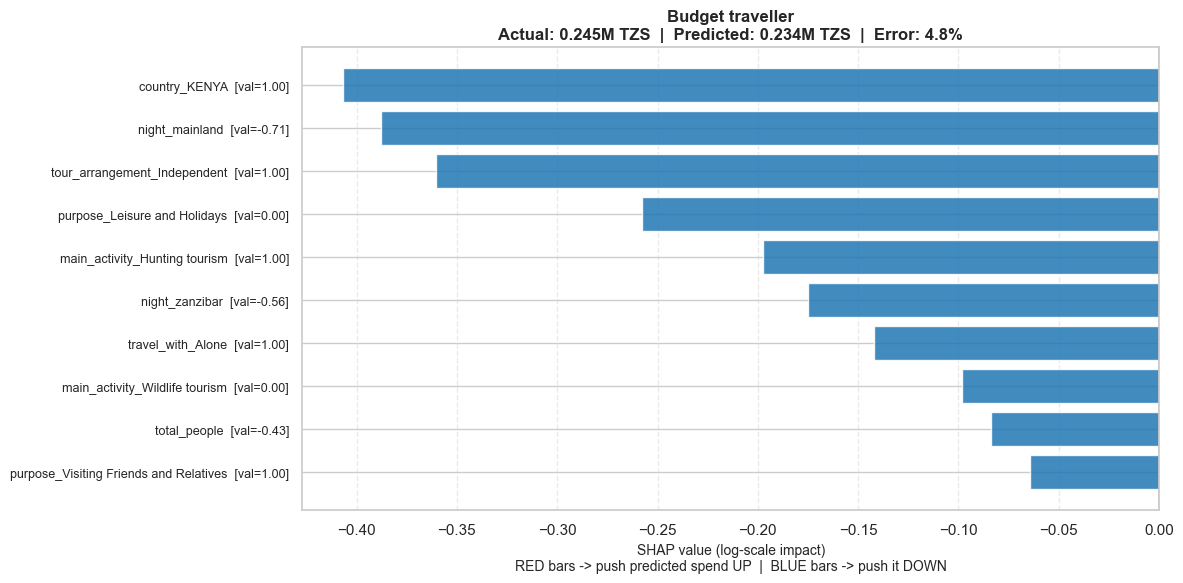

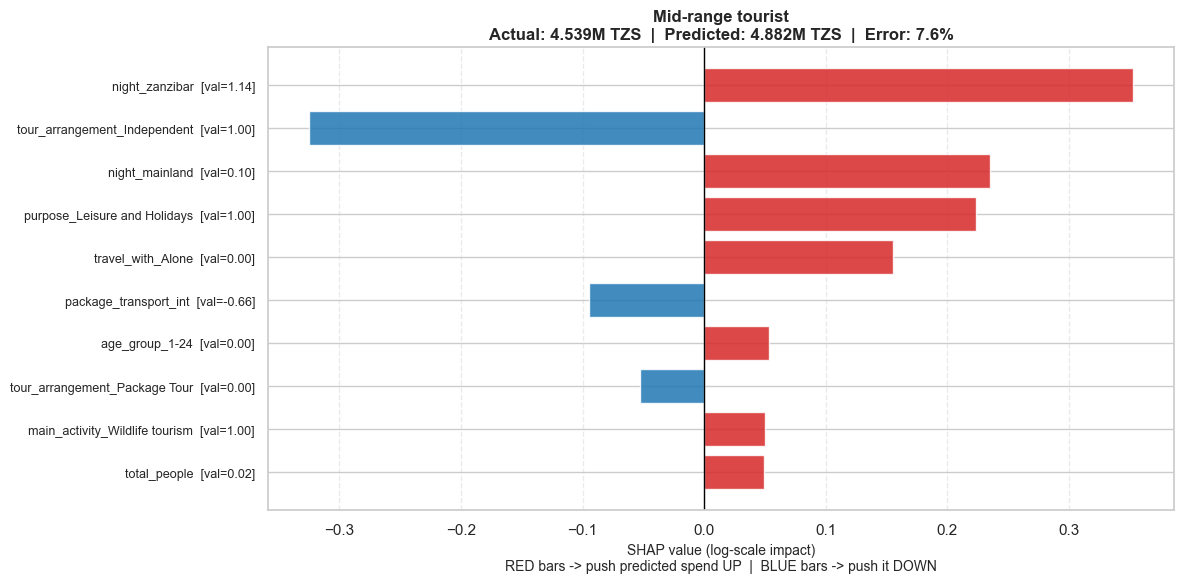

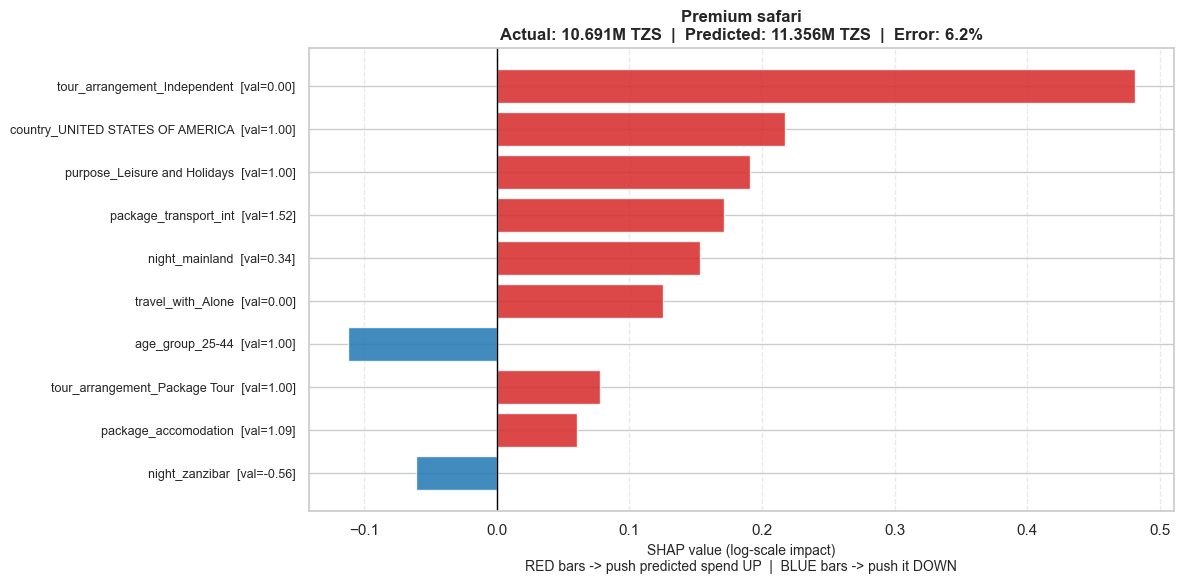

In [57]:
for r in results:
    idx      = r['idx']
    shap_row = shap_values[idx]

    top_n   = 10
    top_idx = np.argsort(np.abs(shap_row))[-top_n:][::-1]
    top_f   = [all_feat_names[j] for j in top_idx]
    top_s   = shap_row[top_idx]
    top_v   = X_test_pre[idx][top_idx]

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = ['#d62728' if s > 0 else '#1f77b4' for s in top_s[::-1]]
    ax.barh(range(top_n), top_s[::-1], color=colors, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(
        [f"{top_f[top_n-1-j]}  [val={top_v[top_n-1-j]:.2f}]" for j in range(top_n)],
        fontsize=9,
    )
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel(
        "SHAP value (log-scale impact)\n"
        "RED bars -> push predicted spend UP  |  BLUE bars -> push it DOWN",
        fontsize=10,
    )
    ax.set_title(
        f"{r['label']}\n"
        f"Actual: {r['actual']/1e6:.3f}M TZS  |  "
        f"Predicted: {r['pred']/1e6:.3f}M TZS  |  "
        f"Error: {r['err_pct']:.1f}%",
        fontsize=12, fontweight='bold',
    )
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    print()

Tourist #666
  Country      : SOUTH AFRICA
  Tour type    : Independent
  Nights mld   : 9
  Nights zan   : 11
  Group size   : 1
  Purpose      : Leisure and Holidays

  Actual spend :    6,049,875 TZS  (~2,086 EUR)
  Prediction   :    2,835,683 TZS  (~978 EUR)
  Error        : 53.1%


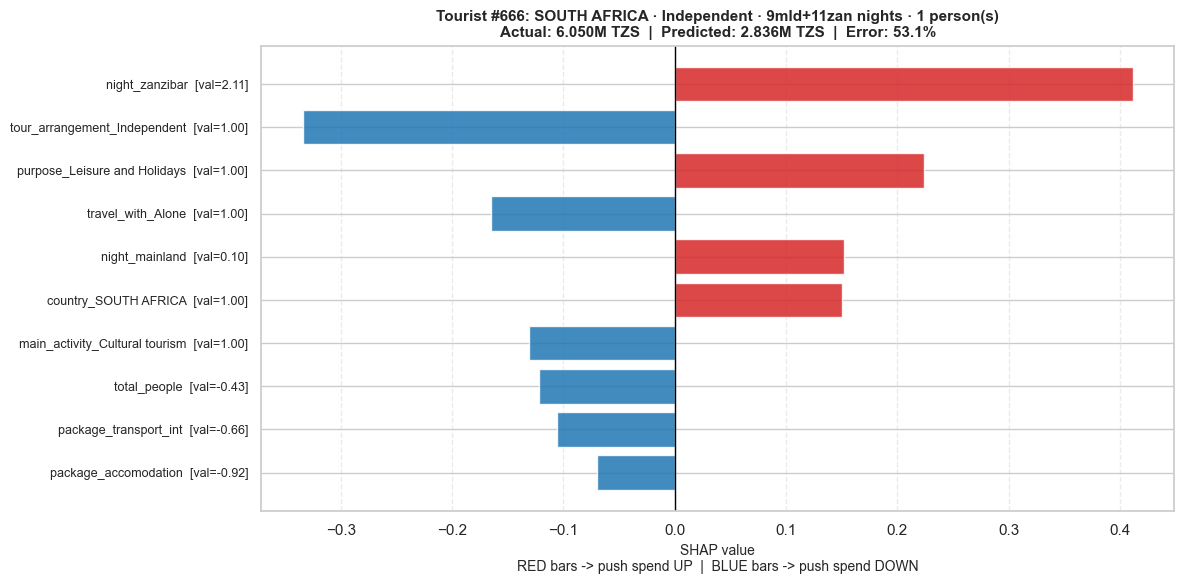

In [58]:
# Change this to any integer 0 .. len(X_test_r)-1
MY_INDEX = 666

row     = X_test_r.iloc[MY_INDEX]
actual  = float(y_test_r.iloc[MY_INDEX])
pred    = float(y_test_pred_xgb_tuned[MY_INDEX])
err_pct = abs(actual - pred) / actual * 100

print(f"Tourist #{MY_INDEX}")
print(f"  Country      : {row['country']}")
print(f"  Tour type    : {row['tour_arrangement']}")
print(f"  Nights mld   : {int(row['night_mainland'])}")
print(f"  Nights zan   : {int(row['night_zanzibar'])}")
print(f"  Group size   : {int(row['total_people'])}")
print(f"  Purpose      : {row['purpose']}")
print()
print(f"  Actual spend : {actual:>12,.0f} TZS  (~{actual/2900:,.0f} EUR)")
print(f"  Prediction   : {pred:>12,.0f} TZS  (~{pred/2900:,.0f} EUR)")
print(f"  Error        : {err_pct:.1f}%")

# Waterfall
shap_row = shap_values[MY_INDEX]
top_n    = 10
top_idx  = np.argsort(np.abs(shap_row))[-top_n:][::-1]
top_f    = [all_feat_names[j] for j in top_idx]
top_s    = shap_row[top_idx]
top_v    = X_test_pre[MY_INDEX][top_idx]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if s > 0 else '#1f77b4' for s in top_s[::-1]]
ax.barh(range(top_n), top_s[::-1], color=colors, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(
    [f"{top_f[top_n-1-j]}  [val={top_v[top_n-1-j]:.2f}]" for j in range(top_n)],
    fontsize=9,
)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(
    "SHAP value\n"
    "RED bars -> push spend UP  |  BLUE bars -> push spend DOWN",
    fontsize=10,
)
ax.set_title(
    f"Tourist #{MY_INDEX}: {row['country']} · {row['tour_arrangement']} · "
    f"{int(row['night_mainland'])}mld+{int(row['night_zanzibar'])}zan nights · "
    f"{int(row['total_people'])} person(s)\n"
    f"Actual: {actual/1e6:.3f}M TZS  |  Predicted: {pred/1e6:.3f}M TZS  |  Error: {err_pct:.1f}%",
    fontsize=11, fontweight='bold',
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()